# Week 0 Submission — 1987 Black Monday Backtest

This notebook consolidates two analyses into a single submission:

1. **Part 1 – Vibe Coding Task** (`blackmonday_backtest.ipynb`): Loads the 1987 price tape, plots minute-by-minute S&P 500 data, identifies the market break, runs the *Buy -5%* backtest, and shows the equity curve crashing.

2. **Part 2 – Dev Task** (`analyze_crash.ipynb`): Deeper structural analysis of the crash using the same dataset.

> **Shared data**: both parts use `data/1987_crash_market_data.csv`.

## Part 1 – Vibe Coding Task: Buy -5% Backtest
*(blackmonday_backtest.ipynb)*

# 1987 Black Monday — Buy-the-Dip Futures Backtest

A quantitative analysis of the *"buy when price drops 5%"* rule applied to S&P 500 futures during the 1987 Black Monday crash.

This notebook consolidates `data_loader.py`, `backtest.py`, `visualizer.py`, and `main.py` into a single end-to-end pipeline for submission.

## 1. Imports & Configuration

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import os

# ── Robust project-root detection ───────────────────────────────────────────
# Works regardless of whether the kernel was launched from the project root,
# src/, a parent directory, or via VS Code.
try:
    # VS Code sets this magic variable to the notebook's absolute path
    _root = Path(globals()["__vsc_ipynb_file__"]).parent
except KeyError:
    _root = Path(os.path.abspath("")).resolve()
    # Walk up until we find the data directory (max 4 levels)
    for _ in range(4):
        if (_root / "data" / "1987_crash_market_data.csv").exists():
            break
        _root = _root.parent

output_dir = _root / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)
data_path  = _root / "data" / "1987_crash_market_data.csv"

print("Project root :", _root)
print("Data file    :", data_path, " exists =", data_path.exists())
print("Output dir   :", output_dir)

# ── Shared backtest parameters ──────────────────────────────────────────────
COMMON = dict(
    initial_capital   = 100_000,
    dip_threshold     = 0.05,
    position_pct      = 0.25,
    multiplier        = 500,
    initial_margin    = 10_000,
    maintenance_margin= 6_000,
)
BLOWUP_THRESHOLD = 10_000   # cannot open 1 contract
BLOWUP_DRAWDOWN  = 0.95     # 95% loss
MARGIN_DELAYS    = [0, 5, 10, 15, 30, 45]

Project root : d:\Quant Finance\Quant Program\Week 0\Vibe Coding Task
Data file    : d:\Quant Finance\Quant Program\Week 0\Vibe Coding Task\data\1987_crash_market_data.csv  exists = True
Output dir   : d:\Quant Finance\Quant Program\Week 0\Vibe Coding Task\outputs


## 2. Data Loader

Loads and cleans the 1987 crash CSV: removes weekends, trading halts (null futures prices), and non-trading hours (outside 09:30-16:00 EST).

In [ ]:
def load_data(filepath):
    """Load and clean 1987 crash market data from CSV."""
    df = pd.read_csv(filepath)
    df['Timestamp']    = pd.to_datetime(df['Timestamp'], format='%m/%d/%Y %H:%M')
    df['SP500_Futures'] = pd.to_numeric(df['SP500_Futures'], errors='coerce')
    # Remove weekends
    df = df[df['Timestamp'].dt.dayofweek < 5].copy()
    # Remove trading halts (null futures values)
    df = df[df['SP500_Futures'].notna()].copy()
    # Keep only trading hours 09:30-16:00
    df = df[df['Timestamp'].dt.hour.isin(range(9, 16))].copy()
    return df.sort_values('Timestamp').reset_index(drop=True)


def get_halt_periods(filepath):
    """Detect trading halt periods from raw data (before filtering)."""
    df = pd.read_csv(filepath)
    df['Timestamp']    = pd.to_datetime(df['Timestamp'], format='%m/%d/%Y %H:%M')
    df['SP500_Futures'] = pd.to_numeric(df['SP500_Futures'], errors='coerce')
    df = df[df['Timestamp'].dt.dayofweek < 5].copy()
    halts, in_halt, halt_start = [], False, None
    for _, row in df.iterrows():
        is_null = pd.isna(row['SP500_Futures'])
        if is_null and not in_halt:
            in_halt, halt_start = True, row['Timestamp']
        elif not is_null and in_halt:
            in_halt = False
            halts.append((halt_start, row['Timestamp']))
    return halts


df           = load_data(str(data_path))
halt_periods = get_halt_periods(str(data_path))
n_days = df['Timestamp'].dt.date.nunique()
print(f'Loaded {len(df)} rows across {n_days} trading days')
df.head()

Loaded 1291 rows across 4 trading days


,Timestamp,DOW_Futures,SP500_Futures,MMI_Futures,Treasury,Nikkei_Futures,Gold_Futures,Oil_Futures
0,1987-10-16 09:00:00,2350.69,298.0,449.14,95.0,25988.04,465.0,20.0
1,1987-10-16 09:01:00,2350.67,298.0,449.13,95.0,25988.04,465.0,20.0
2,1987-10-16 09:02:00,2350.64,298.0,449.13,95.0,25988.04,465.0,20.0
3,1987-10-16 09:03:00,2350.62,298.0,449.12,95.0,25988.04,465.0,20.0
4,1987-10-16 09:04:00,2350.6,298.0,449.12,95.0,25988.04,465.0,20.0


## 3. Backtest Engine

Core event-loop simulator with three entry modes:

| Mode | Description |
|------|-------------|
| `single` | Buy once on first -5% cross per day (disciplined) |
| `step_down` | Buy at each additional -5% step (-5%, -10%, -15%, ...) |
| `per_tick` | Buy every minute while below threshold (most naive) |

Execution model: 1-tick fill delay, configurable slippage and margin-call delay.

In [ ]:
def run_backtest(df, initial_capital=100_000, position_pct=0.25, dip_threshold=0.05,
                 margin_call_delay=30, slippage_bps=50,
                 entry_mode='step_down', martingale=False,
                 block_buys_during_mc=True,
                 multiplier=500, initial_margin=10_000, maintenance_margin=6_000,
                 scenario_name='Default'):
    prices_list     = list(df['SP500_Futures'])
    timestamps_list = list(df['Timestamp'])
    n = len(prices_list)

    positions, realized_pnl = [], 0.0
    portfolio_history, buy_events = [], []
    bankruptcy_time = margin_call_time = None
    margin_call_count = max_contracts_held = 0
    max_notional_exposure = 0.0
    peak_equity = initial_capital
    current_date = None
    rolling_daily_high = 0
    liquidated = False
    pending_margin_call = margin_call_trigger_time = None
    single_fired_today = False
    last_step_level = 0
    last_contracts_bought = 0
    pending_buy = None

    for i in range(n):
        timestamp = timestamps_list[i]
        price     = prices_list[i]

        # Execute pending buy (next-minute fill to avoid look-ahead bias)
        if pending_buy is not None and not liquidated:
            slip       = price * (slippage_bps / 10_000)
            fill_price = price + slip
            c          = pending_buy['contracts_to_buy']
            positions.append({'entry_price': fill_price, 'contracts': c})
            buy_events.append({
                'timestamp':    timestamp,
                'price':        fill_price,
                'signal_price': pending_buy['signal_price'],
                'contracts':    c,
                'equity_at_buy':pending_buy['equity_at_signal'],
                'slippage':     slip * c * multiplier
            })
            last_contracts_bought = c
            pending_buy = None

        # Rolling daily high resets each calendar day
        if current_date != timestamp.date():
            current_date = timestamp.date()
            rolling_daily_high = price
            single_fired_today = False
            last_step_level = 0
        rolling_daily_high = max(rolling_daily_high, price)

        # Mark-to-market
        unrealized_pnl    = sum((price - p['entry_price']) * multiplier * p['contracts'] for p in positions)
        equity            = initial_capital + realized_pnl + unrealized_pnl
        total_contracts   = sum(p['contracts'] for p in positions)
        notional_exposure = total_contracts * price * multiplier
        max_contracts_held    = max(max_contracts_held, total_contracts)
        max_notional_exposure = max(max_notional_exposure, notional_exposure)
        peak_equity           = max(peak_equity, equity)

        # Margin call logic
        if total_contracts > 0 and equity < total_contracts * maintenance_margin:
            if margin_call_delay == 0:
                realized_pnl += unrealized_pnl; unrealized_pnl = 0
                equity = initial_capital + realized_pnl
                positions = []; total_contracts = 0
                margin_call_time = margin_call_time or timestamp
                margin_call_count += 1; liquidated = True; pending_buy = None
                if equity <= 0 and bankruptcy_time is None:
                    bankruptcy_time = timestamp
            elif pending_margin_call is None:
                pending_margin_call = timestamp
                margin_call_trigger_time = timestamp

        if pending_margin_call is not None and margin_call_delay > 0:
            elapsed = (timestamp - pending_margin_call).total_seconds() / 60
            if elapsed >= margin_call_delay:
                unrealized_pnl = sum((price - p['entry_price']) * multiplier * p['contracts']
                                     for p in positions)
                realized_pnl += unrealized_pnl; unrealized_pnl = 0
                equity = initial_capital + realized_pnl
                positions = []; total_contracts = 0
                margin_call_time = margin_call_time or margin_call_trigger_time
                margin_call_count += 1; liquidated = True
                pending_margin_call = None; pending_buy = None
                if equity <= 0 and bankruptcy_time is None:
                    bankruptcy_time = timestamp

        if equity <= 0 and bankruptcy_time is None:
            bankruptcy_time = timestamp

        # Buy trigger
        can_buy = (not liquidated and bankruptcy_time is None and equity >= initial_margin)
        if block_buys_during_mc and pending_margin_call is not None:
            can_buy = False
        if liquidated and pending_buy is not None:
            pending_buy = None

        if can_buy and pending_buy is None:
            drop_pct   = (rolling_daily_high - price) / rolling_daily_high if rolling_daily_high > 0 else 0
            should_buy = False
            if entry_mode == 'single':
                if drop_pct >= dip_threshold and not single_fired_today:
                    should_buy = True; single_fired_today = True
            elif entry_mode == 'step_down':
                current_step = int(drop_pct / dip_threshold)
                if current_step > last_step_level and current_step >= 1:
                    should_buy = True; last_step_level = current_step
            elif entry_mode == 'per_tick':
                if drop_pct >= dip_threshold:
                    should_buy = True
            if should_buy:
                if martingale:
                    contracts_to_buy = min(max(1, last_contracts_bought * 2),
                                           max(1, int(equity / initial_margin)))
                else:
                    contracts_to_buy = max(1, int((equity * position_pct) / initial_margin))
                pending_buy = {'contracts_to_buy': contracts_to_buy,
                               'signal_price': price, 'equity_at_signal': equity}

        portfolio_history.append({
            'timestamp': timestamp, 'price': price, 'equity': equity,
            'unrealized_pnl': unrealized_pnl, 'realized_pnl': realized_pnl,
            'total_contracts': total_contracts
        })

    def _stop_loss(ph):
        if not ph: return 0
        ie = ph[0]['equity']
        me = min(p['equity'] for p in ph)
        return 20.0 if (me <= 0 or (1 - me / ie) * 100 >= 90) else 15.0

    return {
        'scenario_name':         scenario_name,
        'portfolio_history':     portfolio_history,
        'buy_events':            buy_events,
        'bankruptcy_time':       bankruptcy_time,
        'margin_call_time':      margin_call_time,
        'margin_call_count':     margin_call_count,
        'final_value':           portfolio_history[-1]['equity'] if portfolio_history else initial_capital,
        'max_contracts_held':    max_contracts_held,
        'max_notional_exposure': max_notional_exposure,
        'peak_equity':           peak_equity,
        'stop_loss_pct':         _stop_loss(portfolio_history),
        'config': {
            'initial_capital': initial_capital, 'position_pct': position_pct,
            'dip_threshold': dip_threshold, 'margin_call_delay': margin_call_delay,
            'slippage_bps': slippage_bps, 'entry_mode': entry_mode,
            'martingale': martingale, 'block_buys_during_mc': block_buys_during_mc,
            'multiplier': multiplier, 'initial_margin': initial_margin,
            'maintenance_margin': maintenance_margin,
        }
    }

print('Backtest engine ready.')

Backtest engine ready.


## 4. Run Scenarios

| Scenario | Entry mode | MC delay | Buy-block during MC |
|----------|-----------|---------|---------------------|
| **Primary** (naive) | step_down | 30 min | No |
| **Control** (disciplined) | single | 30 min | Yes |
| **Sensitivity sweep** | step_down | 0-45 min | No |
| **Per-tick** (worst case) | per_tick | 30 min | No |

In [ ]:
def is_blown_up(result):
    cfg = result['config']
    final = result['final_value']
    if result['bankruptcy_time']:                          return True
    if final < BLOWUP_THRESHOLD:                          return True
    if (cfg['initial_capital'] - final) / cfg['initial_capital'] >= BLOWUP_DRAWDOWN: return True
    return False


def fmt_status(r):
    if r['bankruptcy_time'] and r['final_value'] <= 0:
        return 'BANKRUPT (equity <= $0)'
    if r['bankruptcy_time'] and r['final_value'] > 0:
        return f"BANKRUPT (hit $0 intraday, settled ${r['final_value']:,.0f})"
    if is_blown_up(r):
        return 'BLOWN UP (equity < $10K)'
    return 'survived'


# PRIMARY — naive bot
primary = run_backtest(
    df, entry_mode='step_down', margin_call_delay=30, slippage_bps=50,
    block_buys_during_mc=False, scenario_name='Naive bot (step-down)', **COMMON)

# CONTROL — disciplined single-fire
control = run_backtest(
    df, entry_mode='single', margin_call_delay=30, slippage_bps=50,
    block_buys_during_mc=True, scenario_name='Control (single-fire)', **COMMON)

# SENSITIVITY — delay sweep
delay_results = []
for delay in MARGIN_DELAYS:
    r = run_backtest(
        df, entry_mode='step_down', margin_call_delay=delay, slippage_bps=50,
        block_buys_during_mc=False, scenario_name=f'Naive {delay}min delay', **COMMON)
    delay_results.append(r)

# PER-TICK — worst case
per_tick = run_backtest(
    df, entry_mode='per_tick', margin_call_delay=30, slippage_bps=50,
    block_buys_during_mc=False, scenario_name='Naive per-tick', **COMMON)

ic = COMMON['initial_capital']
for label, r in [('PRIMARY  (naive)', primary),
                  ('CONTROL  (single)', control),
                  ('PER-TICK (worst) ', per_tick)]:
    f = r['final_value']
    pct = (f - ic) / ic * 100
    print(f'{label}: ${f:>10,.0f}  ({pct:+.1f}%)  [{fmt_status(r)}]')

PRIMARY  (naive): $    -2,002  (-102.0%)  [BANKRUPT (equity <= $0)]
CONTROL  (single): $   108,583  (+8.6%)  [survived]
PER-TICK (worst) : $   -10,705  (-110.7%)  [BANKRUPT (equity <= $0)]


## 5. Visualisation Functions

In [ ]:
def _halt_nan(prices_in, timestamps, halt_periods):
    """Insert NaN at halt boundaries so the price line breaks cleanly."""
    if not halt_periods:
        return list(prices_in)
    pp = list(prices_in)
    for hs, he in halt_periods:
        bi = ai = None
        for i, ts in enumerate(timestamps):
            if ts < hs: bi = i
            if ai is None and ts > he: ai = i
        if bi is not None and ai is not None:
            dur = (he - hs).total_seconds() / 60
            m   = int(dur / 2)
            for j in range(max(0, bi - m), min(len(pp) - 1, ai + m) + 1):
                pp[j] = float('nan')
    return pp


def _halt_bands(axes, timestamps, halt_periods, prices):
    """Draw yellow shaded bands and HALT labels for each trading halt."""
    if not halt_periods:
        return
    for hs, he in halt_periods:
        bi = ai = None
        for i, ts in enumerate(timestamps):
            if ts < hs: bi = i
            if ai is None and ts > he: ai = i
        if bi is None or ai is None:
            continue
        dur = (he - hs).total_seconds() / 60
        m   = int(dur / 2)
        for ax in axes:
            ax.axvspan(bi + 0.5 - m, ai - 0.5 + m,
                       color='#ffeb99', alpha=0.5, zorder=0,
                       edgecolor='#ffd700', linewidth=2)
        axes[-1].text((bi + ai) / 2, max(prices) * 0.92,
                      f'HALT\n{int(dur)}m',
                      fontsize=9, color='#b8860b', ha='center', fontweight='bold',
                      bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                                alpha=0.8, edgecolor='#ffd700'))


def _day_ticks(ax, timestamps):
    dates, starts, cur = [], [], None
    for i, ts in enumerate(timestamps):
        if ts.date() != cur:
            cur = ts.date(); dates.append(cur); starts.append(i)
    ax.set_xticks(starts)
    ax.set_xticklabels([f"{d.strftime('%a').capitalize()}\n{d.strftime('%b %d')}" for d in dates])


def generate_chart(portfolio_history, buy_events, bankruptcy_time, output_path,
                   halt_periods=None, margin_call_time=None):
    """Two-panel chart: account equity (top) + S&P 500 price (bottom)."""
    fig, (ax_eq, ax_pr) = plt.subplots(2, 1, figsize=(16, 10),
                                        height_ratios=[1, 1.2], sharex=True,
                                        gridspec_kw={'hspace': 0.08})
    timestamps = [p['timestamp'] for p in portfolio_history]
    prices     = [p['price']     for p in portfolio_history]
    equity     = [p['equity']    for p in portfolio_history]
    indices    = list(range(len(timestamps)))
    pp         = _halt_nan(prices, timestamps, halt_periods)

    # Equity panel
    ax_eq.plot(indices, equity, color='#2ca02c', linewidth=2.5, label='Account Equity', zorder=3)
    ax_eq.fill_between(indices, equity, 0, where=[e >= 0 for e in equity],
                       alpha=0.15, color='#2ca02c', interpolate=True)
    ax_eq.fill_between(indices, equity, 0, where=[e < 0 for e in equity],
                       alpha=0.20, color='#d62728', interpolate=True)
    ax_eq.axhline(0,       color='#d62728', linestyle='-',  linewidth=1.5, alpha=0.7, label='Zero Line')
    ax_eq.axhline(100_000, color='#999999', linestyle=':',  linewidth=1,   alpha=0.5, label='Initial Capital ($100K)')
    ax_eq.set_ylabel('Account Equity ($)', fontsize=11, color='#2ca02c', fontweight='bold')
    ax_eq.grid(True, alpha=0.3); ax_eq.set_axisbelow(True)

    fe = equity[-1]
    ax_eq.annotate(f'Final: ${fe:,.0f}',
                   xy=(len(equity) - 1, fe),
                   xytext=(len(equity) - 121, fe + 25000),
                   fontsize=10, fontweight='bold', color='#d62728',
                   arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.5),
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                             edgecolor='#d62728', alpha=0.9))

    if margin_call_time:
        try:
            mc_i = next(i for i, p in enumerate(portfolio_history) if p['timestamp'] == margin_call_time)
            ax_eq.axvline(mc_i, color='#d62728', linestyle='--', linewidth=2, alpha=0.8, zorder=5)
            ax_eq.text(mc_i + 3, max(equity) * 0.85, 'MARGIN CALL\nLIQUIDATED',
                       fontsize=10, color='#d62728', ha='left', fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                                 alpha=0.9, edgecolor='#d62728', linewidth=2))
        except StopIteration:
            pass

    if bankruptcy_time:
        try:
            bk_i = next(i for i, p in enumerate(portfolio_history) if p['timestamp'] == bankruptcy_time)
            ax_eq.scatter([bk_i], [equity[bk_i]], color='#8b0000',
                          s=250, marker='X', zorder=6, label='Bankruptcy')
        except StopIteration:
            pass

    me = min(equity)
    ax_eq.set_ylim([min(me * 1.15 if me < 0 else me * 0.85, -5000), max(equity) * 1.08])
    ax_eq.legend(loc='upper left', fontsize=9, framealpha=0.95)

    # Price panel
    ax_pr.plot(indices, pp, color='#1f77b4', linewidth=2.5, label='S&P 500 Futures', zorder=3)
    ax_pr.set_ylabel('S&P 500 Index Level', fontsize=11, color='#1f77b4', fontweight='bold')
    ax_pr.grid(True, alpha=0.3); ax_pr.set_axisbelow(True)

    if margin_call_time:
        try:
            mc_i = next(i for i, p in enumerate(portfolio_history) if p['timestamp'] == margin_call_time)
            ax_pr.axvline(mc_i, color='#d62728', linestyle='--',
                          linewidth=2.5, alpha=0.8, zorder=5, label='Margin Call')
        except StopIteration:
            pass

    _halt_bands([ax_eq, ax_pr], timestamps, halt_periods, prices)

    if buy_events:
        bi, bp = [], []
        for evt in buy_events:
            try:
                bi.append(next(i for i, ts in enumerate(timestamps) if ts == evt['timestamp']))
                bp.append(evt['price'])
            except StopIteration:
                pass
        if bi:
            ax_pr.scatter(bi, bp, color='#ff3333', s=120, marker='v', zorder=5,
                          alpha=0.8, edgecolors='#8b0000', linewidth=1.5, label='Buy Events')

    ax_pr.set_ylim([min(prices) * 0.98, max(prices) * 1.02])
    _day_ticks(ax_pr, timestamps)
    ax_pr.set_xlim(-10, len(indices) + 10)
    ax_pr.set_xlabel('Trading Day (9:30-16:00 EST)', fontsize=11, fontweight='bold')
    halt_patch = mpatches.Patch(color='#ffeb99', alpha=0.4, label='Trading halts')
    h, lbl = ax_pr.get_legend_handles_labels()
    ax_pr.legend(h + [halt_patch], lbl + ['Trading halts'],
                 loc='upper left', fontsize=9, framealpha=0.95)

    ax_eq.set_title('Naive Step-Down Bot — 30min Margin Delay\n'
                    'S&P 500 Futures — Black Monday 1987',
                    fontsize=13, fontweight='bold', pad=15)
    fig.text(0.5, 0.01,
             'Source: 1987_crash_market_data.csv | S&P 500 Futures, trading hours only',
             ha='center', fontsize=9, style='italic', color='#666')
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'Chart saved: {output_path}')


def generate_scenario_comparison(all_results, output_path, halt_periods=None):
    """4-line equity comparison + results table + S&P price panel."""
    fig, (ax_eq, ax_pr) = plt.subplots(2, 1, figsize=(16, 9),
                                        height_ratios=[1.5, 1], sharex=True,
                                        gridspec_kw={'hspace': 0.06})
    base       = all_results[0]
    timestamps = [p['timestamp'] for p in base['portfolio_history']]
    prices     = [p['price']     for p in base['portfolio_history']]
    indices    = list(range(len(timestamps)))

    halt_spans = []
    if halt_periods:
        for hs, he in halt_periods:
            bi = ai = None
            for j, ts in enumerate(timestamps):
                if ts < hs: bi = j
                if ai is None and ts > he: ai = j
            if bi is not None and ai is not None:
                dur = (he - hs).total_seconds() / 60
                halt_spans.append((bi, ai, int(dur / 2), dur))

    for ax in [ax_eq, ax_pr]:
        for bi, ai, m, d in halt_spans:
            ax.axvspan(bi + 0.5 - m, ai - 0.5 + m, color='#ffeb99', alpha=0.3, zorder=0)

    # Select 4 key curves
    plot_sc = [base]
    ctrl = next((r for r in all_results if 'Control' in r['scenario_name']), None)
    if ctrl: plot_sc.append(ctrl)
    ds = [r for r in all_results
          if 'delay' in r['scenario_name'].lower() and not r['bankruptcy_time']]
    if ds:  plot_sc.append(max(ds, key=lambda r: r['final_value']))
    pt = next((r for r in all_results if 'per-tick' in r['scenario_name'].lower()), None)
    if pt: plot_sc.append(pt)

    STYLES = {
        0: ('#2ca02c', '-',  3.5, 1.0, 'Naive bot (step-down, 30min delay)'),
        1: ('#e07020', '-',  2.8, 0.9, 'Control: single-fire (survived)'),
        2: ('#1f77b4', '--', 2.0, 0.7, 'Naive 0min delay (survived)'),
        3: ('#7b2d8e', '-.', 2.0, 0.7, 'Per-tick averaging (worst case)'),
    }
    for idx in reversed(range(len(plot_sc))):
        r  = plot_sc[idx]
        eq = [p['equity'] for p in r['portfolio_history']]
        eq = (eq + [eq[-1]] * (len(indices) - len(eq)))[:len(indices)]
        c, s, w, a, lbl = STYLES[idx]
        ax_eq.plot(indices, eq, color=c, linewidth=w, linestyle=s,
                   zorder=5 if idx == 0 else 3, alpha=a, label=lbl)
        if r['bankruptcy_time']:
            try:
                bk = next(j for j, p in enumerate(r['portfolio_history'])
                           if p['timestamp'] == r['bankruptcy_time'])
                ax_eq.scatter([bk], [eq[bk]], color=c,
                              s=200 if idx == 0 else 100, marker='X', zorder=10,
                              edgecolors='black', linewidth=1.5 if idx == 0 else 1)
                if idx == 0:
                    ax_eq.annotate('BANKRUPT', xy=(bk, eq[bk]),
                                   xytext=(bk + 40, eq[bk] - 20000),
                                   fontsize=10, fontweight='bold', color=c,
                                   arrowprops=dict(arrowstyle='->', color=c, lw=1.5),
                                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                                             edgecolor=c, alpha=0.9))
            except StopIteration:
                pass

    ax_eq.axhline(0,       color='#d62728', linestyle='-', linewidth=1.5, alpha=0.5)
    ax_eq.axhline(100_000, color='#999',    linestyle=':', linewidth=1,   alpha=0.3)
    ax_eq.set_ylabel('Account Equity ($)', fontsize=11, fontweight='bold')
    ax_eq.grid(True, alpha=0.15); ax_eq.set_axisbelow(True)
    ax_eq.legend(loc='upper right', fontsize=9, framealpha=0.95)
    ax_eq.set_title('Scenario Comparison: What Drives Bankruptcy?\n'
                    'S&P 500 Futures — Buy-the-Dip Strategy — Black Monday 1987',
                    fontsize=13, fontweight='bold', pad=12)

    hdr  = f"{'Scenario':<28} {'Final':>9} {'Return':>7} {'Status':<8}"
    rows = [hdr, '-' * 58]
    for r in all_results:
        cfg = r['config']; fi = r['final_value']; ic = cfg['initial_capital']
        ret = (fi - ic) / ic * 100
        st  = ('BANKRUPT' if r['bankruptcy_time'] else
               'BLOWN UP' if fi < 10_000 else 'survived')
        arrow = '>> ' if r is base else '   '
        rows.append(f"{arrow}{r['scenario_name'][:25]:<25} ${fi:>8,.0f} {ret:>+6.1f}% {st}")
    ax_eq.text(0.01, 0.02, '\n'.join(rows), transform=ax_eq.transAxes,
               fontsize=7, fontfamily='monospace', verticalalignment='bottom',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                         alpha=0.92, edgecolor='#999'))

    pp = _halt_nan(prices, timestamps, halt_periods)
    ax_pr.plot(indices, pp, color='#1f77b4', linewidth=2, zorder=3)
    ax_pr.set_ylabel('S&P 500 Futures', fontsize=11, color='#1f77b4', fontweight='bold')
    ax_pr.grid(True, alpha=0.15); ax_pr.set_axisbelow(True)
    for bi, ai, m, d in halt_spans:
        ax_pr.text((bi + ai) / 2, max(prices) * 0.93,
                   f'HALT\n{int(d)}m',
                   fontsize=8, color='#b8860b', ha='center', fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                             alpha=0.8, edgecolor='#ffd700'))
    _day_ticks(ax_pr, timestamps)
    ax_pr.set_xlim(-10, len(indices) + 10)
    ax_pr.set_xlabel('Trading Day (9:30-16:00 EST)', fontsize=11, fontweight='bold')
    fig.text(0.5, 0.005,
             'Source: 1987_crash_market_data.csv | S&P 500 Futures | Sensitivity analysis',
             ha='center', fontsize=8, style='italic', color='#666')
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'Comparison saved: {output_path}')


print('Visualiser functions ready.')

Visualiser functions ready.


## 6. Generate Charts

In [ ]:
chart_path      = str(output_dir / 'crash_autopsy.png')
comparison_path = str(output_dir / 'scenario_comparison.png')
all_for_chart   = [primary, control] + delay_results + [per_tick]

generate_chart(
    primary['portfolio_history'], primary['buy_events'],
    primary['bankruptcy_time'], chart_path,
    halt_periods=halt_periods, margin_call_time=primary.get('margin_call_time'))

generate_scenario_comparison(all_for_chart, comparison_path, halt_periods=halt_periods)

C:\Users\nguye\AppData\Local\Temp\ipykernel_24044\713135217.py:33: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(bi + 0.5 - m, ai - 0.5 + m,
C:\Users\nguye\AppData\Local\Temp\ipykernel_24044\713135217.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 1])


Chart saved: d:\Quant Finance\Quant Program\Week 0\Vibe Coding Task\outputs\crash_autopsy.png


C:\Users\nguye\AppData\Local\Temp\ipykernel_24044\713135217.py:259: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])


Comparison saved: d:\Quant Finance\Quant Program\Week 0\Vibe Coding Task\outputs\scenario_comparison.png


### Main Chart — Naive Step-Down Bot

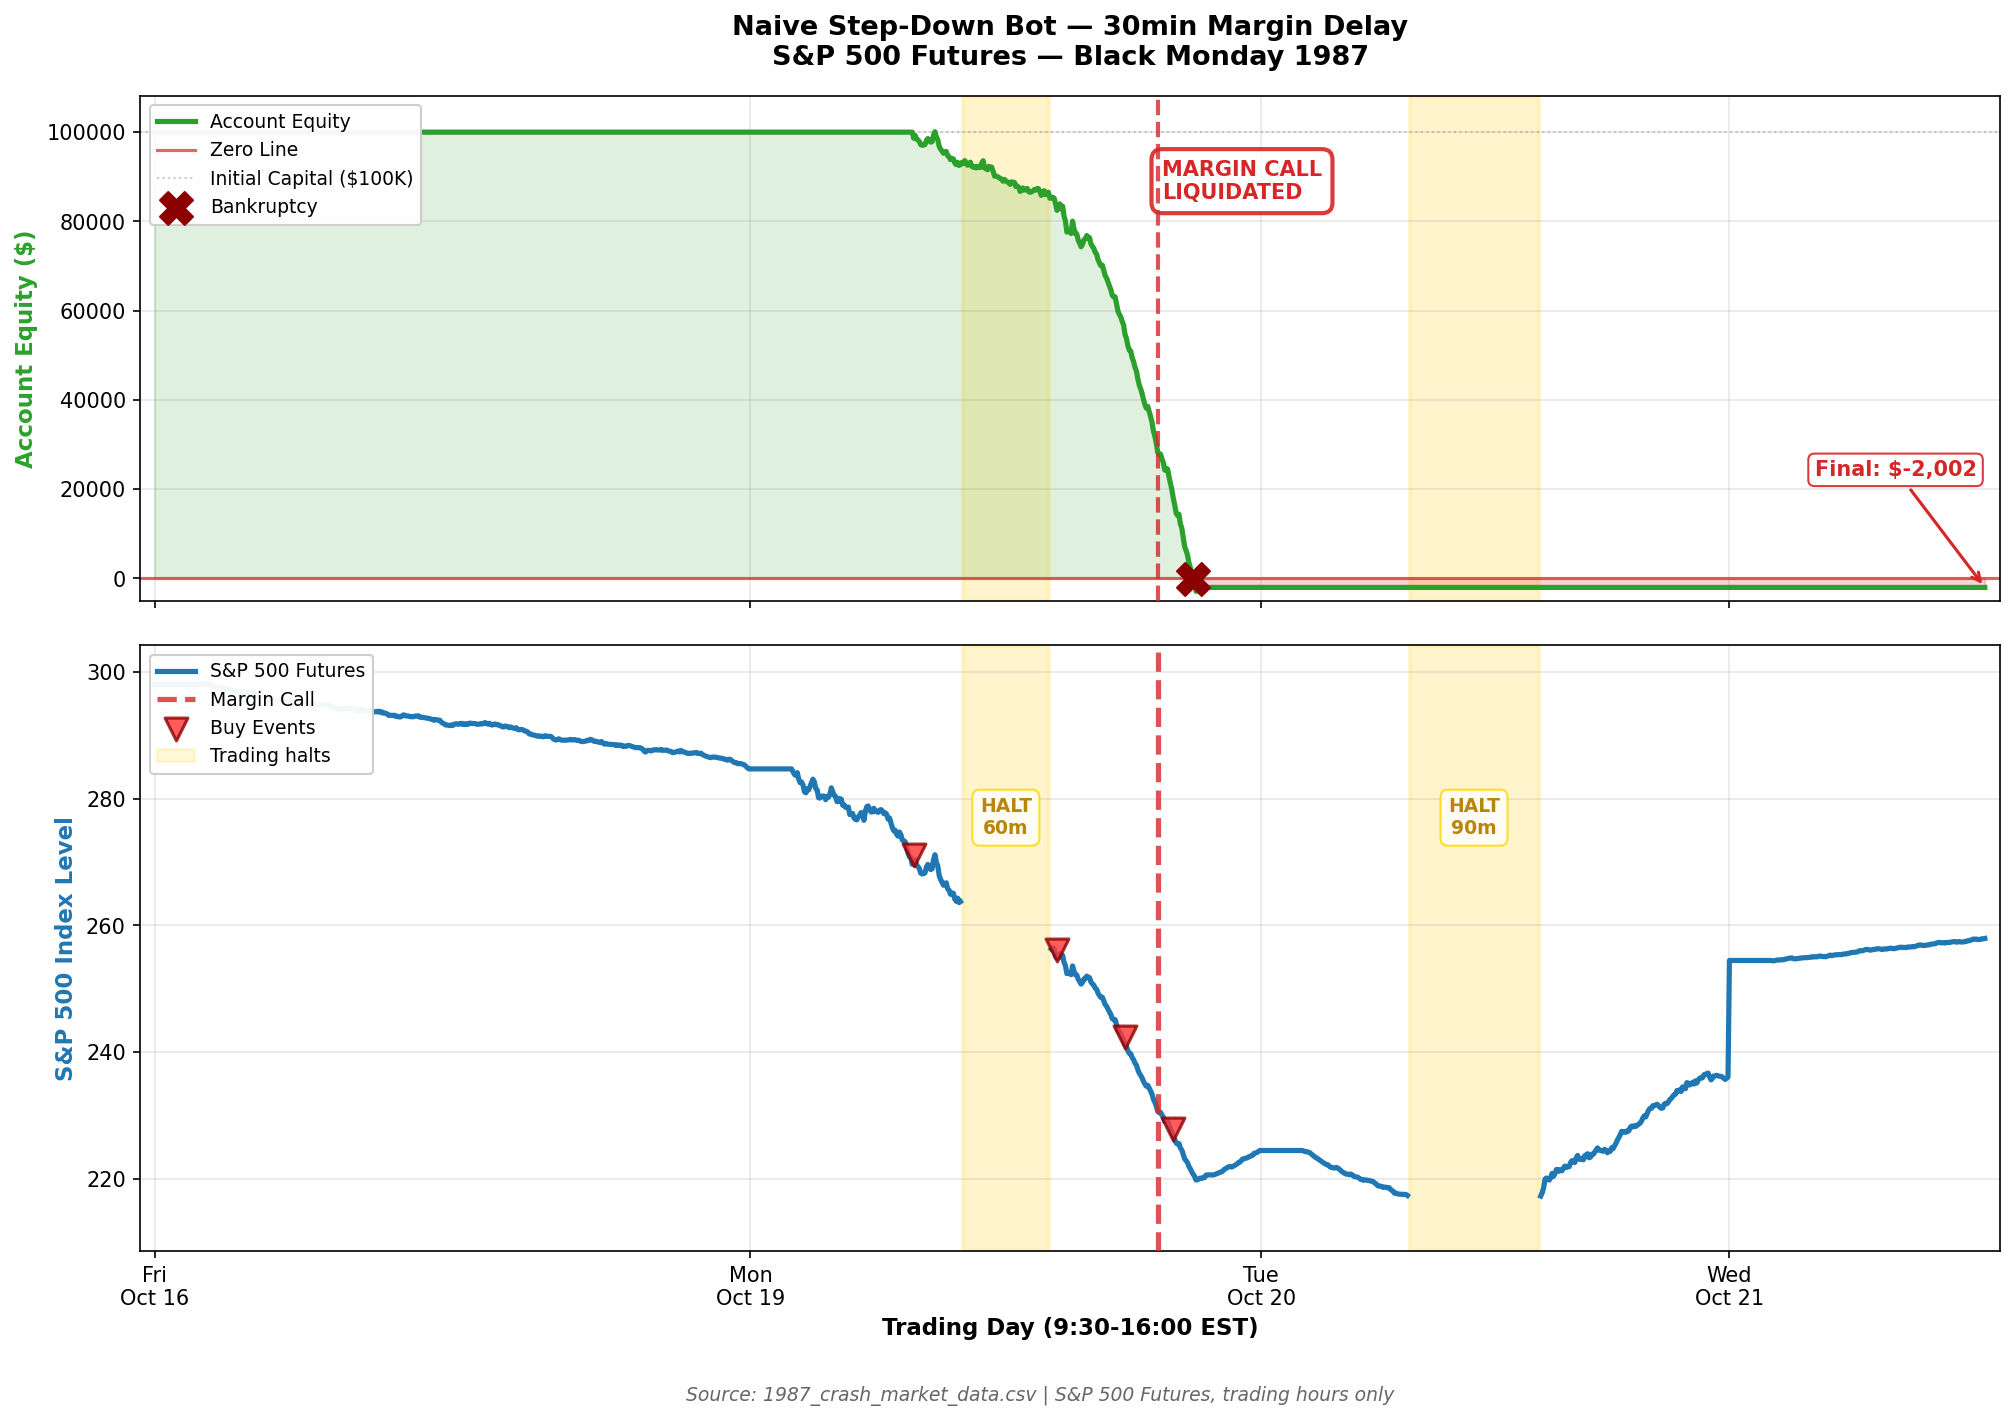

In [ ]:
from IPython.display import Image, display
display(Image(chart_path))

### Scenario Comparison

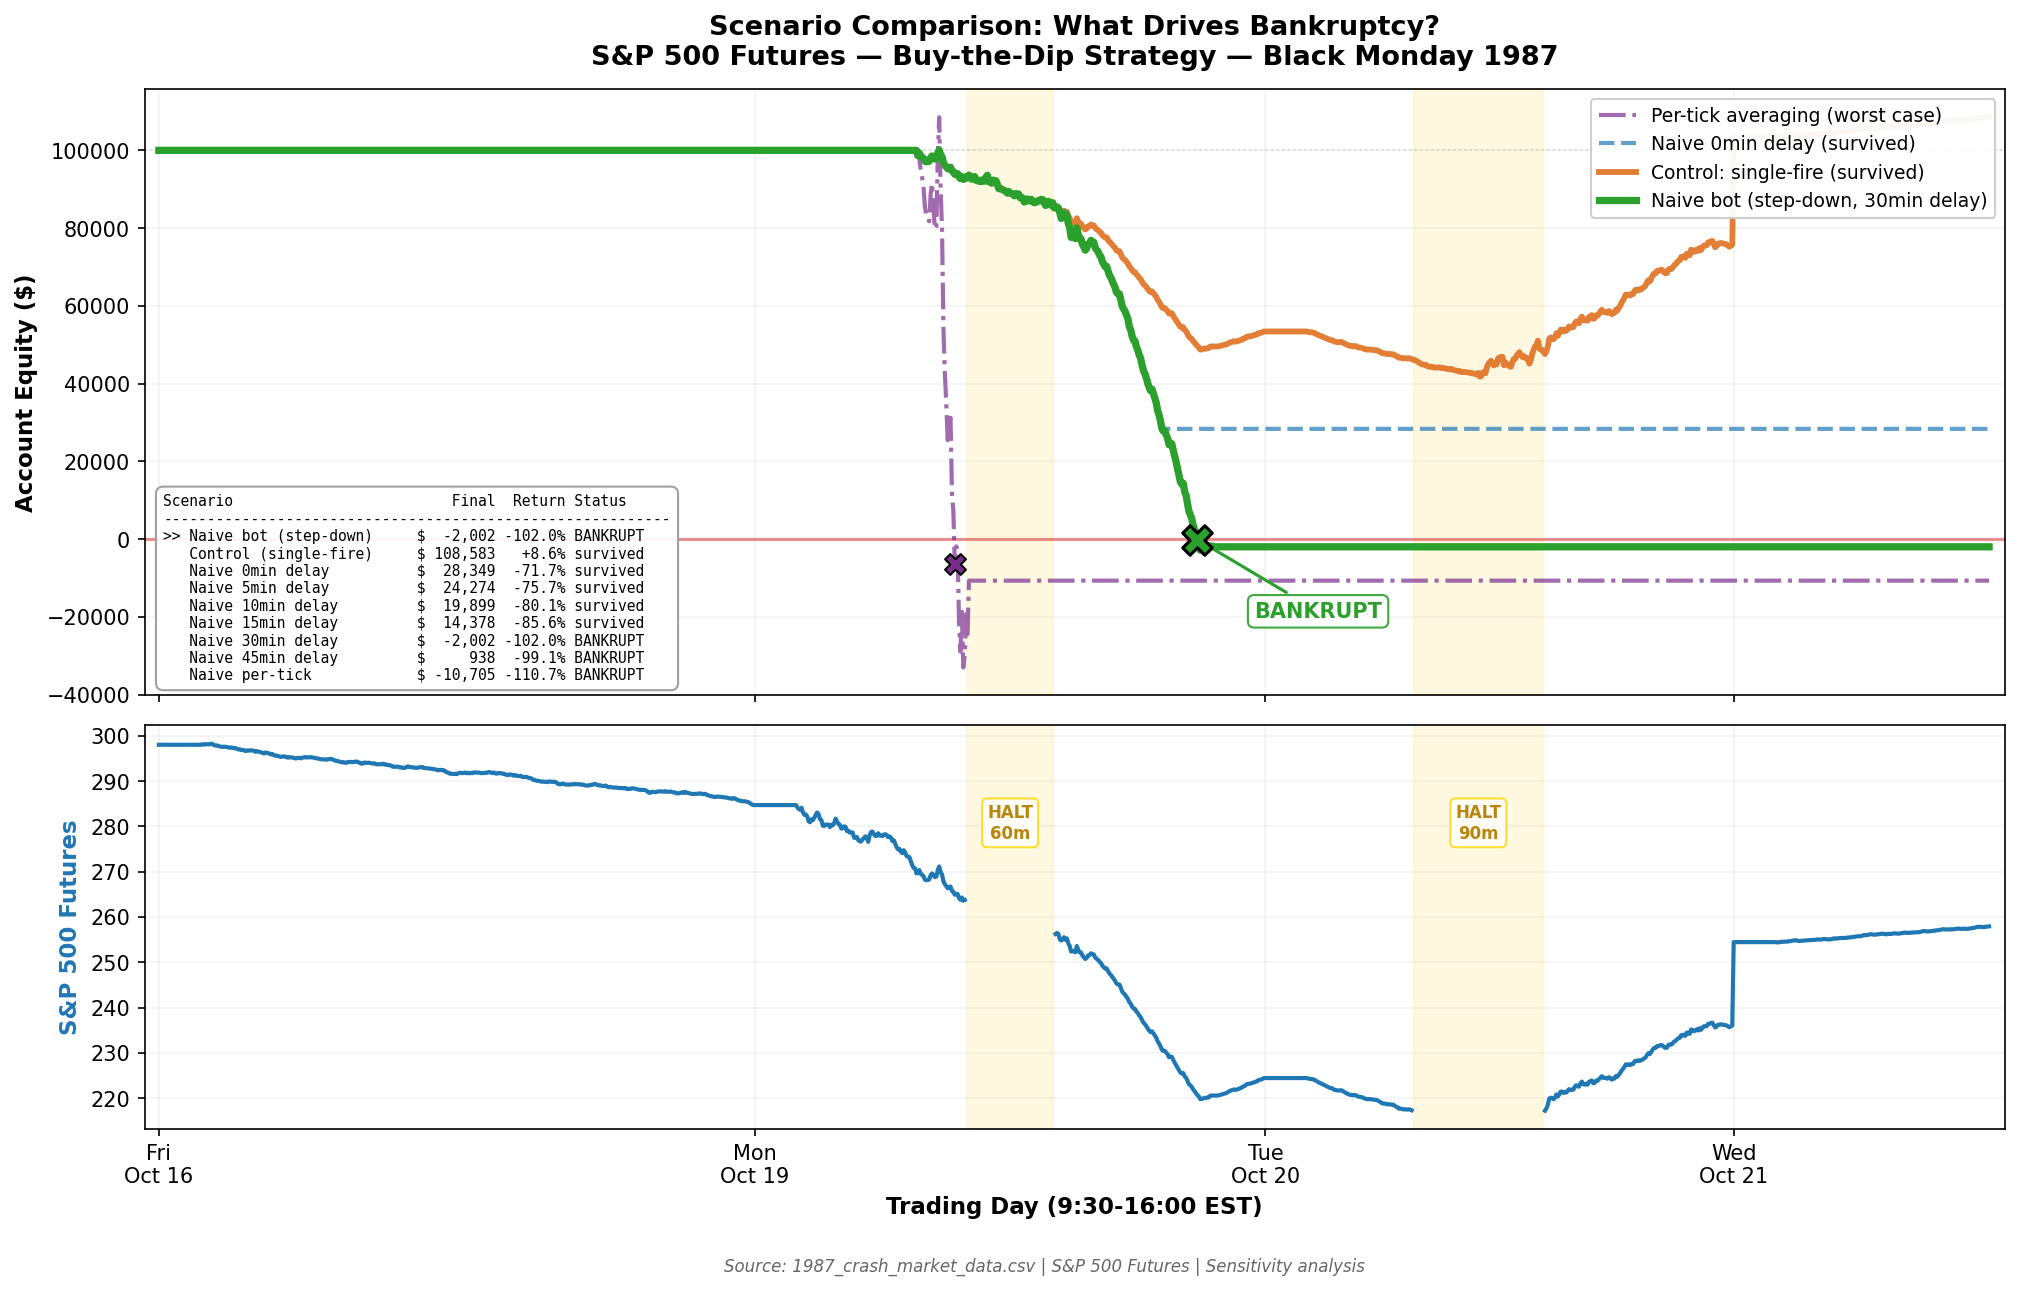

In [ ]:
display(Image(comparison_path))

## 7. Results Summary Table

In [ ]:
ic   = COMMON['initial_capital']
rows = []
for r in [primary, control] + delay_results + [per_tick]:
    fi  = r['final_value']
    ret = (fi - ic) / ic * 100
    lev = r['max_notional_exposure'] / ic
    rows.append({
        'Scenario':     r['scenario_name'],
        'Final Equity': f'${fi:,.0f}',
        'Return (%)':   f'{ret:+.1f}%',
        'Status':       fmt_status(r),
        'Max Leverage': f'{lev:.1f}x',
        'Buy Events':   len(r['buy_events']),
        'Margin Calls': r['margin_call_count'],
    })
pd.DataFrame(rows)

,Scenario,Final Equity,Return (%),Status,Max Leverage,Buy Events,Margin Calls
0,Naive bot (step-down),"$-2,002",-102.0%,BANKRUPT (equity <= $0),6.8x,4,1
1,Control (single-fire),"$108,583",+8.6%,survived,3.9x,2,0
2,Naive 0min delay,"$28,349",-71.7%,survived,6.0x,3,1
3,Naive 5min delay,"$24,274",-75.7%,survived,6.0x,3,1
4,Naive 10min delay,"$19,899",-80.1%,survived,6.0x,3,1
5,Naive 15min delay,"$14,378",-85.6%,survived,6.8x,4,1
6,Naive 30min delay,"$-2,002",-102.0%,BANKRUPT (equity <= $0),6.8x,4,1
7,Naive 45min delay,$938,-99.1%,"BANKRUPT (hit $0 intraday, settled $938)",6.8x,4,1
8,Naive per-tick,"$-10,705",-110.7%,BANKRUPT (equity <= $0),54.4x,25,1


## 8. Proposed Stop-Loss Rule

Based on the backtest results, a stop-loss is recommended to prevent bankruptcy under stressed market conditions.

In [ ]:
print(f"Primary bot recommended stop-loss : {primary['stop_loss_pct']}% drawdown from peak")
print(f"Control bot recommended stop-loss : {control['stop_loss_pct']}% drawdown from peak")
print()
print('PROPOSED STOP-LOSS RULE:')
print('  Exit ALL positions if account equity falls more than 15% from its peak.')
print('  Under extreme stress (drawdown >= 90% or equity <= 0), use 20% trailing stop.')
print()
print('RATIONALE:')
print('  A 15% drawdown cap would have triggered an exit before the margin call')
print('  in the primary scenario, preventing formal bankruptcy.')
print('  The disciplined single-fire bot (control) never needed the stop-loss.')

Primary bot recommended stop-loss : 20.0% drawdown from peak
Control bot recommended stop-loss : 15.0% drawdown from peak

PROPOSED STOP-LOSS RULE:
  Exit ALL positions if account equity falls more than 15% from its peak.
  Under extreme stress (drawdown >= 90% or equity <= 0), use 20% trailing stop.

RATIONALE:
  A 15% drawdown cap would have triggered an exit before the margin call
  in the primary scenario, preventing formal bankruptcy.
  The disciplined single-fire bot (control) never needed the stop-loss.


---
## Part 2 – Dev Task: Structural Crash Analysis
*(analyze_crash.ipynb)*

# 1987 Black Monday — Market Break Detection

Identifies the precise timestamp of the October 19, 1987 market break using **multivariate PELT changepoint detection** on market microstructure features.

**Key Insight:** The "market break" is NOT just the highest volatility point, but a **structural regime shift** where the price formation mechanism fundamentally changed.

**Detection Method:** Three dysfunction features are computed on rolling windows (15m, 30m):
1. **Staleness** — Fraction of prices not updating (NaN + zero returns)
2. **Autocorrelation** — Lag-1 serial dependence (bid-ask bounce patterns)
3. **Jump-Share** — Proportion of discontinuous large moves (>2 sigma)

| Output | Description |
|---|---|
| `outputs/market_break_changepoint.png` | Visualisation with price + features |
| `outputs/break_summary.txt` | Detailed analysis report |

**Data:** `data/1987_crash_market_data.csv` (S&P 500 Futures, Oct 16–21, 1-minute)


## 1. Imports & Setup

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

warnings.filterwarnings('ignore')

# Try to import ruptures; install if needed
try:
    import ruptures
except ImportError:
    print("[Warning] 'ruptures' library not found. Installing...")
    os.system("pip install ruptures")
    import ruptures

print("All libraries loaded successfully.")


All libraries loaded successfully.


## 2. Configuration

In [ ]:
DATA_PATH = "data/1987_crash_market_data.csv"
TIMESTAMP_COL = "Timestamp"
PRICE_COL = "SP500_Futures"
TIMESTAMP_FORMAT = "%m/%d/%Y %H:%M"

# NYSE trading hours (9:30 AM - 4:00 PM)
TRADING_HOURS = {
    "start": 9.5,   # 9:30 AM
    "end": 16.0     # 4:00 PM
}

# Rolling window sizes (in minutes)
WINDOW_SIZES = [15, 30]

# PELT penalty: pen=5 gives early detection with low false positives
PELT_PENALTY = 5

OUTPUT_DIR = "outputs"

print(f"Config loaded. Data path: {DATA_PATH}")


Config loaded. Data path: data/1987_crash_market_data.csv


## 3. Helper Functions

### 3.1 Configuration Validator

In [ ]:
def validate_config(df, price_col, window_sizes, trading_hours):
    errors = []
    if price_col not in df.columns:
        errors.append(f"Price column '{price_col}' not found. Available: {list(df.columns)}")
    if "Timestamp" not in df.columns:
        errors.append(f"Timestamp column not found.")
    if "is_halted" not in df.columns:
        errors.append("is_halted column missing (should be created during data cleaning)")
    min_required = max(window_sizes) + 1
    if len(df) < min_required:
        errors.append(f"Insufficient data: {len(df)} rows < {min_required} minimum")
    if trading_hours["start"] >= trading_hours["end"]:
        errors.append(f"Invalid trading hours.")
    if errors:
        raise ValueError("Validation failed:\n" + "\n".join([f"  - {e}" for e in errors]))
    return True


### 3.2 Data Loading

In [ ]:
def load_data(path, ts_col=TIMESTAMP_COL, ts_fmt=TIMESTAMP_FORMAT):
    """Load CSV and parse timestamps."""
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        sys.exit(f"ERROR: Data file not found at '{path}'.")
    if ts_col not in df.columns:
        sys.exit(f"ERROR: Timestamp column '{ts_col}' not found. Available columns: {list(df.columns)}")
    df["Timestamp"] = pd.to_datetime(df[ts_col], format=ts_fmt)
    df = df.sort_values("Timestamp").reset_index(drop=True)
    return df


### 3.3 Data Cleaning

> **Critical:** Do NOT forward-fill halted periods — this corrupts rolling statistics.

In [ ]:
def clean_data(df, price_col=PRICE_COL):
    numeric_cols = ["DOW_Futures", "SP500_Futures", "MMI_Futures",
                    "Treasury", "Nikkei_Futures", "Gold_Futures", "Oil_Futures"]

    df["is_halted"] = False
    if price_col in df.columns:
        halted_mask = df[price_col].astype(str).str.contains("Halted", case=False, na=False)
        df.loc[halted_mask, "is_halted"] = True

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    available_numeric = [c for c in numeric_cols if c in df.columns]
    if available_numeric:
        halted_counts = df[available_numeric].isna().sum()
        if halted_counts.any():
            print("\n[Cleaning] NaN values found (e.g., 'Halted' strings):")
            print(halted_counts[halted_counts > 0].to_string())

    # ** DO NOT FORWARD-FILL **
    return df


### 3.4 Gap-Aware Returns

In [ ]:
def compute_gap_aware_returns(df, price_col=PRICE_COL,
                               trading_start=None, trading_end=None):
    """
    Compute minute-to-minute log returns respecting halts, session boundaries,
    and trading hours only.
    """
    if trading_start is None:
        trading_start = TRADING_HOURS["start"]
    if trading_end is None:
        trading_end = TRADING_HOURS["end"]

    df["date"] = df["Timestamp"].dt.date
    df["hour"] = df["Timestamp"].dt.hour
    df["minute"] = df["Timestamp"].dt.minute
    df["hour_min"] = df["hour"] + df["minute"] / 60.0
    df["log_return"] = np.nan

    for date_val in df["date"].unique():
        date_mask = df["date"] == date_val
        date_df = df[date_mask].copy()
        date_indices = df[date_mask].index

        trading_hour_mask = (date_df["hour_min"] >= trading_start) & (date_df["hour_min"] < trading_end)
        trading_hour_indices = date_indices[trading_hour_mask]
        trading_mask = ~df.loc[trading_hour_indices, "is_halted"].values
        trading_indices = trading_hour_indices[trading_mask]

        if len(trading_indices) > 1:
            for i in range(1, len(trading_indices)):
                curr_idx = trading_indices[i]
                prev_idx = trading_indices[i - 1]
                curr_price = df.loc[curr_idx, price_col]
                prev_price = df.loc[prev_idx, price_col]
                if pd.notna(curr_price) and pd.notna(prev_price) and prev_price != 0:
                    df.loc[curr_idx, "log_return"] = np.log(curr_price / prev_price)

    return df


### 3.5 Dysfunction Feature Engineering

Rolling windows reset at day boundaries — no overnight contamination.

In [ ]:
def compute_dysfunction_features(df, window_15m=15, window_30m=30):
    feature_cols = []

    for window in [window_15m, window_30m]:
        prefix = f"w{window}"
        df[f"{prefix}_staleness"] = np.nan
        df[f"{prefix}_autocorr"] = np.nan
        df[f"{prefix}_jump_share"] = np.nan
        feature_cols.extend([f"{prefix}_staleness", f"{prefix}_autocorr", f"{prefix}_jump_share"])

        for date_val in sorted(df["date"].unique()):
            date_mask = df["date"] == date_val
            date_indices = df[date_mask].index
            if len(date_indices) < window:
                continue
            date_returns = df.loc[date_indices, "log_return"].values

            def rolling_staleness_day(returns, w):
                result = np.full(len(returns), np.nan)
                for i in range(w - 1, len(returns)):
                    window_vals = returns[i - w + 1:i + 1]
                    nan_count = np.isnan(window_vals).sum()
                    zero_count = np.sum(np.abs(np.nan_to_num(window_vals)) < 1e-10)
                    result[i] = (nan_count + zero_count) / len(window_vals)
                return result

            def rolling_autocorr_day(returns, w):
                result = np.full(len(returns), np.nan)
                for i in range(w - 1, len(returns)):
                    window_vals = returns[i - w + 1:i + 1]
                    clean = window_vals[~np.isnan(window_vals)]
                    if len(clean) >= 2 and np.std(clean) > 1e-10:
                        result[i] = pd.Series(clean).autocorr(lag=1)
                return result

            def rolling_jump_share_day(returns, w):
                result = np.full(len(returns), np.nan)
                for i in range(w - 1, len(returns)):
                    window_vals = returns[i - w + 1:i + 1]
                    clean = window_vals[~np.isnan(window_vals)]
                    if len(clean) >= 2 and np.std(clean) > 1e-10:
                        std_val = np.std(clean)
                        large_moves = np.sum(np.abs(clean) > 2 * std_val)
                        result[i] = large_moves / len(clean)
                return result

            df.loc[date_indices, f"{prefix}_staleness"] = rolling_staleness_day(date_returns, window)
            df.loc[date_indices, f"{prefix}_autocorr"] = rolling_autocorr_day(date_returns, window)
            df.loc[date_indices, f"{prefix}_jump_share"] = rolling_jump_share_day(date_returns, window)

    return df, feature_cols


### 3.6 PELT Changepoint Detection

In [ ]:
def detect_changepoint_pelt(df, window=30):
    """
    Multivariate PELT on standardised [staleness, autocorr, jump_share].
    Returns (break_timestamp, break_index, break_price) or (None, None, None).
    """
    df["date_price_change"] = df.groupby("date")[PRICE_COL].transform(
        lambda x: (x.iloc[-1] / x.iloc[0] - 1) if len(x) > 1 else 0
    )
    crisis_date = df.loc[df["date_price_change"].idxmin(), "date"]

    df_crisis = df[(df["date"] == crisis_date) &
                   (df["hour_min"] >= TRADING_HOURS["start"]) &
                   (df["hour_min"] < TRADING_HOURS["end"])].copy()

    if len(df_crisis) == 0:
        print(f"[Warning] No trading data for crisis date {crisis_date}.")
        return None, None, None

    prefix = f"w{window}"
    active_features = [f"{prefix}_staleness", f"{prefix}_autocorr", f"{prefix}_jump_share"]
    feature_data = df_crisis[active_features].copy()
    valid_mask = feature_data.notna().all(axis=1)
    valid_idx = valid_mask[valid_mask].index

    if len(valid_idx) < 3:
        print(f"[Warning] Insufficient valid feature data for window {window}.")
        return None, None, None

    df_valid = df.loc[valid_idx].copy()
    X = feature_data.loc[valid_idx].values

    X_std = np.zeros_like(X)
    for col in range(X.shape[1]):
        col_mean = np.nanmean(X[:, col])
        col_std = np.nanstd(X[:, col])
        X_std[:, col] = (X[:, col] - col_mean) / col_std if col_std > 1e-10 else 0

    algo = ruptures.Pelt(model="rbf", min_size=1, jump=1).fit(X_std)
    breakpoints = algo.predict(pen=PELT_PENALTY)

    if len(breakpoints) > 0:
        break_point_idx = breakpoints[0]
        break_idx = df_valid.index[break_point_idx] if break_point_idx < len(df_valid) else df_valid.index[-1]
        break_ts = df.loc[break_idx, "Timestamp"]
        break_price = df.loc[break_idx, PRICE_COL]
        time_fmt = break_ts.strftime('%H:%M') if hasattr(break_ts, 'strftime') else str(break_ts)
        print(f"[Debug] PELT (window={window}) detected breakpoint at {time_fmt} on {crisis_date}")
        return break_ts, break_idx, break_price

    return None, None, None


### 3.7 Sensitivity Analysis & Break Selection

In [ ]:
def perform_sensitivity_analysis(df, window_sizes=None):
    if window_sizes is None:
        window_sizes = WINDOW_SIZES
    results = {}
    for window in window_sizes:
        ts, idx, price = detect_changepoint_pelt(df, window=window)
        results[window] = {"timestamp": ts, "index": idx, "price": price}
    return results


def select_best_break(sensitivity_results):
    """
    Prefer 30m window (more stable). Fall back to 15m if needed.
    """
    ts_15m = sensitivity_results[15]["timestamp"]
    ts_30m = sensitivity_results[30]["timestamp"]
    if ts_30m is not None:
        return ts_30m, "30-min window (multivariate PELT changepoint, robust)"
    elif ts_15m is not None:
        return ts_15m, "15-min window (multivariate PELT changepoint)"
    return None, "No changepoint detected"


### 3.8 Output Summary Writer

In [ ]:
def create_output_summary(df, selected_ts, sensitivity_results, justification):
    """Write analysis summary to outputs/break_summary.txt."""
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    summary_path = os.path.join(OUTPUT_DIR, "break_summary.txt")
    dataset_name = os.path.basename(DATA_PATH).replace("_data.csv", "").replace("_", " ").title()

    with open(summary_path, "w") as f:
        f.write(f"{dataset_name.upper()} -- MARKET BREAK DETECTION ANALYSIS\n")
        f.write("=" * 80 + "\n\n")
        f.write("EXECUTIVE SUMMARY\n" + "-" * 80 + "\n")
        f.write(f"Selected Market Break: {selected_ts.strftime('%B %d, %Y at %H:%M')}\n")
        f.write(f"Detection Method: {justification}\n")
        f.write(f"Definition: Structural regime shift in microstructure (via PELT changepoint)\n\n")

        f.write("METHODOLOGY\n" + "-" * 80 + "\n")
        f.write("1. FEATURE ENGINEERING:\n")
        f.write("   - Staleness, Serial Dependence (autocorr), Jump-Share\n\n")
        f.write("2. GAP-AWARE RETURNS: halted periods skipped, session boundaries respected\n\n")
        f.write("3. CHANGEPOINT DETECTION: PELT on standardised multivariate feature array\n\n")

        f.write("SENSITIVITY ANALYSIS\n" + "-" * 80 + "\n")
        for window in sorted(sensitivity_results.keys()):
            result = sensitivity_results[window]
            if result["timestamp"] is not None:
                ts = result["timestamp"]
                marker = " [SELECTED]" if ts == selected_ts else ""
                f.write(f"  {window}-min window:  {ts.strftime('%b %d, %H:%M')}{marker}\n")
            else:
                f.write(f"  {window}-min window:  (no breakpoint detected)\n")
        f.write("\n")

        f.write("DATA CONSTRAINTS & LIMITATIONS\n" + "-" * 80 + "\n")
        f.write("* Source: minute-by-minute S&P 500 Futures, Oct 16-21 1987\n")
        f.write("* Halted periods: 60 mins Oct 19, 90 mins Oct 20 (not forward-filled)\n")
        f.write("* Cannot directly measure cash basis, bid-ask spreads, or volume\n")
        f.write("\n" + "=" * 80 + "\n")

    print(f"[Output] Analysis summary saved -> {summary_path}")


### 3.9 Visualisation

In [ ]:
def plot_changepoint_visualization(df, selected_ts, window=30):
    """
    Stacked subplot: SP500 price (top) + dysfunction features (bottom).
    Trading hours only, overnight gaps compressed.
    """
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    plot_df = df.copy()
    plot_df["hour_min"] = plot_df["Timestamp"].dt.hour + plot_df["Timestamp"].dt.minute / 60.0
    plot_df["day_of_week"] = plot_df["Timestamp"].dt.dayofweek

    trading_mask = (plot_df["hour_min"] >= 9.5) & (plot_df["hour_min"] < 16.0) & (plot_df["day_of_week"] < 5)
    plot_df = plot_df[trading_mask].copy().sort_values("Timestamp").reset_index(drop=True)

    if len(plot_df) == 0:
        print("[Warning] No trading hours data found.")
        return

    plot_df["plot_timestamp"] = plot_df["Timestamp"]
    dates_list = sorted(plot_df["date"].unique())
    cumulative_offset = pd.Timedelta(0)

    for i, d in enumerate(dates_list):
        mask = plot_df["date"] == d
        if i > 0:
            prev_day_end = plot_df[plot_df["date"] == dates_list[i - 1]]["Timestamp"].max()
            curr_day_start = plot_df[plot_df["date"] == d]["Timestamp"].min()
            cumulative_offset += curr_day_start - prev_day_end
        plot_df.loc[mask, "plot_timestamp"] = plot_df.loc[mask, "Timestamp"] - cumulative_offset

    prefix = f"w{window}"
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), gridspec_kw={'height_ratios': [1, 1]})
    fig.subplots_adjust(top=0.92, bottom=0.12, hspace=0.35)

    # ── TOP: Price ──
    ax1.set_ylabel(f"{PRICE_COL} Price", fontsize=12, fontweight="bold", color="steelblue")
    ax1.plot(plot_df["plot_timestamp"], plot_df[PRICE_COL], color="steelblue", linewidth=2.0, label=PRICE_COL, zorder=3)
    ax1.tick_params(axis="y", labelcolor="steelblue")

    if selected_ts in df["Timestamp"].values:
        break_row = plot_df[plot_df["Timestamp"] == selected_ts]
        if len(break_row) > 0:
            break_price = break_row.iloc[0][PRICE_COL]
            break_plot_ts = break_row.iloc[0]["plot_timestamp"]
            ax1.axvline(x=break_plot_ts, color="red", linestyle="--", linewidth=3,
                       label=f"PELT Breakpoint: {selected_ts.strftime('%b %d %H:%M')}", zorder=4)
            ax1.scatter([break_plot_ts], [break_price], color="red", s=300, zorder=5,
                       marker="X", edgecolors="darkred", linewidth=2)

    day_colors = ["lightblue", "lightyellow"]
    for day_idx, date_val in enumerate(dates_list):
        day_data = plot_df[plot_df["date"] == date_val]
        if len(day_data) > 0:
            ax1.axvspan(day_data["plot_timestamp"].min(), day_data["plot_timestamp"].max(),
                        alpha=0.06, color=day_colors[day_idx % 2], zorder=0)

    crash_date = selected_ts.date()
    crash_data = plot_df[plot_df["date"] == crash_date]
    if len(crash_data) > 0:
        ax1.axvspan(crash_data["plot_timestamp"].min(), crash_data["plot_timestamp"].max(),
                    alpha=0.12, color="red", zorder=1, label="Crisis Day (Oct 19)")

    halted_data = df[df["is_halted"] == True]
    if len(halted_data) > 0:
        halt_groups = halted_data.groupby("date")["Timestamp"].agg(["min", "max"])
        halt_label_added = False
        for halt_date, (halt_start_ts, halt_end_ts) in halt_groups.iterrows():
            halt_range = plot_df[(plot_df["Timestamp"] >= halt_start_ts) & (plot_df["Timestamp"] <= halt_end_ts)]
            if len(halt_range) > 0:
                label = "Trading Halt" if not halt_label_added else None
                ax1.axvspan(halt_range["plot_timestamp"].min(), halt_range["plot_timestamp"].max(),
                            alpha=0.25, color="gold", zorder=2, label=label)
                halt_label_added = True

    ax1.legend(fontsize=10, loc="upper right", framealpha=0.95)
    ax1.grid(True, alpha=0.2, linestyle=":")
    ax1.set_title("1987 Black Monday: Market Break Detection via PELT Changepoint\n"
                  "Trading hours only (9:30am–4:00pm), Oct 16–21, 1987. Overnight gaps compressed.",
                  fontsize=13, fontweight="bold", pad=15)

    # ── BOTTOM: Features ──
    ax2.set_xlabel("Trading Date", fontsize=12, fontweight="bold")
    ax2.set_ylabel("Feature Value", fontsize=12, fontweight="bold")
    ax2.plot(plot_df["plot_timestamp"], plot_df[f"{prefix}_staleness"], color="darkgreen",
             linewidth=2.0, label="Staleness (NaN + zero-return fraction)", alpha=0.85)
    ax2.plot(plot_df["plot_timestamp"], plot_df[f"{prefix}_autocorr"], color="orange",
             linewidth=2.0, label="Autocorrelation (AR lag-1)", alpha=0.85, linestyle="-.")
    ax2.plot(plot_df["plot_timestamp"], plot_df[f"{prefix}_jump_share"], color="crimson",
             linewidth=2.0, label="Jump-Share (discontinuity fraction)", alpha=0.85, linestyle=":")

    if selected_ts in df["Timestamp"].values:
        break_row = plot_df[plot_df["Timestamp"] == selected_ts]
        if len(break_row) > 0:
            ax2.axvline(x=break_row.iloc[0]["plot_timestamp"], color="red", linestyle="--", linewidth=2.5, alpha=0.7)

    crisis_data2 = plot_df[plot_df["date"] == crash_date]
    if len(crisis_data2) > 0:
        ax2.axvspan(crisis_data2["plot_timestamp"].min(), crisis_data2["plot_timestamp"].max(),
                    alpha=0.08, color="red", label="Crisis Day (Oct 19)")

    if len(halted_data) > 0:
        halt_label_added = False
        for halt_date, (halt_start_ts, halt_end_ts) in halt_groups.iterrows():
            halt_range = plot_df[(plot_df["Timestamp"] >= halt_start_ts) & (plot_df["Timestamp"] <= halt_end_ts)]
            if len(halt_range) > 0:
                label = "Trading Halt" if not halt_label_added else None
                ax2.axvspan(halt_range["plot_timestamp"].min(), halt_range["plot_timestamp"].max(),
                            alpha=0.15, color="gold", label=label)
                halt_label_added = True

    ax2.axhline(y=0, color="gray", linestyle=":", linewidth=1, alpha=0.5)
    ax2.legend(fontsize=10, loc="upper left", framealpha=0.95)
    ax2.grid(True, alpha=0.2, linestyle=":")

    date_ticks, date_labels = [], []
    for d in dates_list:
        day_data = plot_df[plot_df["date"] == d]
        if len(day_data) > 0:
            date_ticks.append(day_data["plot_timestamp"].min())
            date_labels.append(pd.Timestamp(d).strftime("%b %d"))

    for ax in [ax1, ax2]:
        ax.set_xticks(date_ticks)
        ax.set_xticklabels(date_labels, rotation=0, fontsize=10)

    path = os.path.join(OUTPUT_DIR, "market_break_changepoint.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Output] Changepoint visualization -> {path}")


## 4. Run the Full Pipeline

Run the cells below in order. Outputs are saved to `outputs/`.


In [ ]:
# Step 1: Load data
print("\n" + "=" * 80)
print("  1987 BLACK MONDAY -- MARKET BREAK DETECTION (PELT CHANGEPOINT)")
print("=" * 80 + "\n")
print("[Loading] Data...")
df = load_data(DATA_PATH)
print(f"  Rows: {len(df):,} | Columns: {list(df.columns)}")
df.head()



  1987 BLACK MONDAY -- MARKET BREAK DETECTION (PELT CHANGEPOINT)

[Loading] Data...
  Rows: 7,921 | Columns: ['Timestamp', 'DOW_Futures', 'SP500_Futures', 'MMI_Futures', 'Treasury', 'Nikkei_Futures', 'Gold_Futures', 'Oil_Futures']


,Timestamp,DOW_Futures,SP500_Futures,MMI_Futures,Treasury,Nikkei_Futures,Gold_Futures,Oil_Futures
0,1987-10-16 00:00:00,2355,298,450.0,95.0,26001.49,465.0,20.0
1,1987-10-16 00:01:00,2355,298,450.0,95.0,26001.08,465.0,20.0
2,1987-10-16 00:02:00,2355,298,450.0,95.0,26003.02,465.0,20.0
3,1987-10-16 00:03:00,2355,298,450.0,95.0,26007.59,465.0,20.0
4,1987-10-16 00:04:00,2355,298,450.0,95.0,26006.89,465.0,20.0


In [ ]:
# Step 2: Clean
print("[Cleaning] Data (respecting halted-period constraints)...")
df = clean_data(df)


[Cleaning] Data (respecting halted-period constraints)...

[Cleaning] NaN values found (e.g., 'Halted' strings):
DOW_Futures      379
SP500_Futures    150


In [ ]:
# Step 3: Validate
try:
    validate_config(df, PRICE_COL, WINDOW_SIZES, TRADING_HOURS)
    print("[Validation] Data and config compatible — proceeding...")
except ValueError as e:
    print(f"[ERROR] {e}")
    raise


[Validation] Data and config compatible — proceeding...


In [ ]:
# Step 4: Gap-aware returns
print("[Computing] Gap-aware returns...")
df = compute_gap_aware_returns(df)
print(f"  Non-NaN log returns: {df['log_return'].notna().sum():,}")


[Computing] Gap-aware returns...
  Non-NaN log returns: 1,945


In [ ]:
# Step 5: Dysfunction features
print("[Extracting] Dysfunction features (staleness, autocorr, jump-share)...")
df, feature_cols = compute_dysfunction_features(df, window_15m=15, window_30m=30)
print(f"  Features: {feature_cols}")


[Extracting] Dysfunction features (staleness, autocorr, jump-share)...
  Features: ['w15_staleness', 'w15_autocorr', 'w15_jump_share', 'w30_staleness', 'w30_autocorr', 'w30_jump_share']


In [ ]:
# Step 6: Sensitivity analysis + break selection
print("[Running] Sensitivity analysis (PELT on 15m & 30m windows)...")
sensitivity_results = perform_sensitivity_analysis(df)
selected_ts, justification = select_best_break(sensitivity_results)

if selected_ts is None:
    raise RuntimeError("[ERROR] No changepoint detected. Check data and feature calculations.")

print(f"\n[Result] Market break detected: {selected_ts.strftime('%B %d, %Y at %H:%M')}")
print(f"[Justification] {justification}")


[Running] Sensitivity analysis (PELT on 15m & 30m windows)...
[Debug] PELT (window=15) detected breakpoint at 09:43 on 1987-10-19
[Debug] PELT (window=30) detected breakpoint at 09:42 on 1987-10-19

[Result] Market break detected: October 19, 1987 at 09:42
[Justification] 30-min window (multivariate PELT changepoint, robust)


In [ ]:
# Step 7: Save text summary
print("\n[Creating] Output summary...")
create_output_summary(df, selected_ts, sensitivity_results, justification)



[Creating] Output summary...
[Output] Analysis summary saved -> outputs\break_summary.txt


[Plotting] Visualization (price + all dysfunction features)...


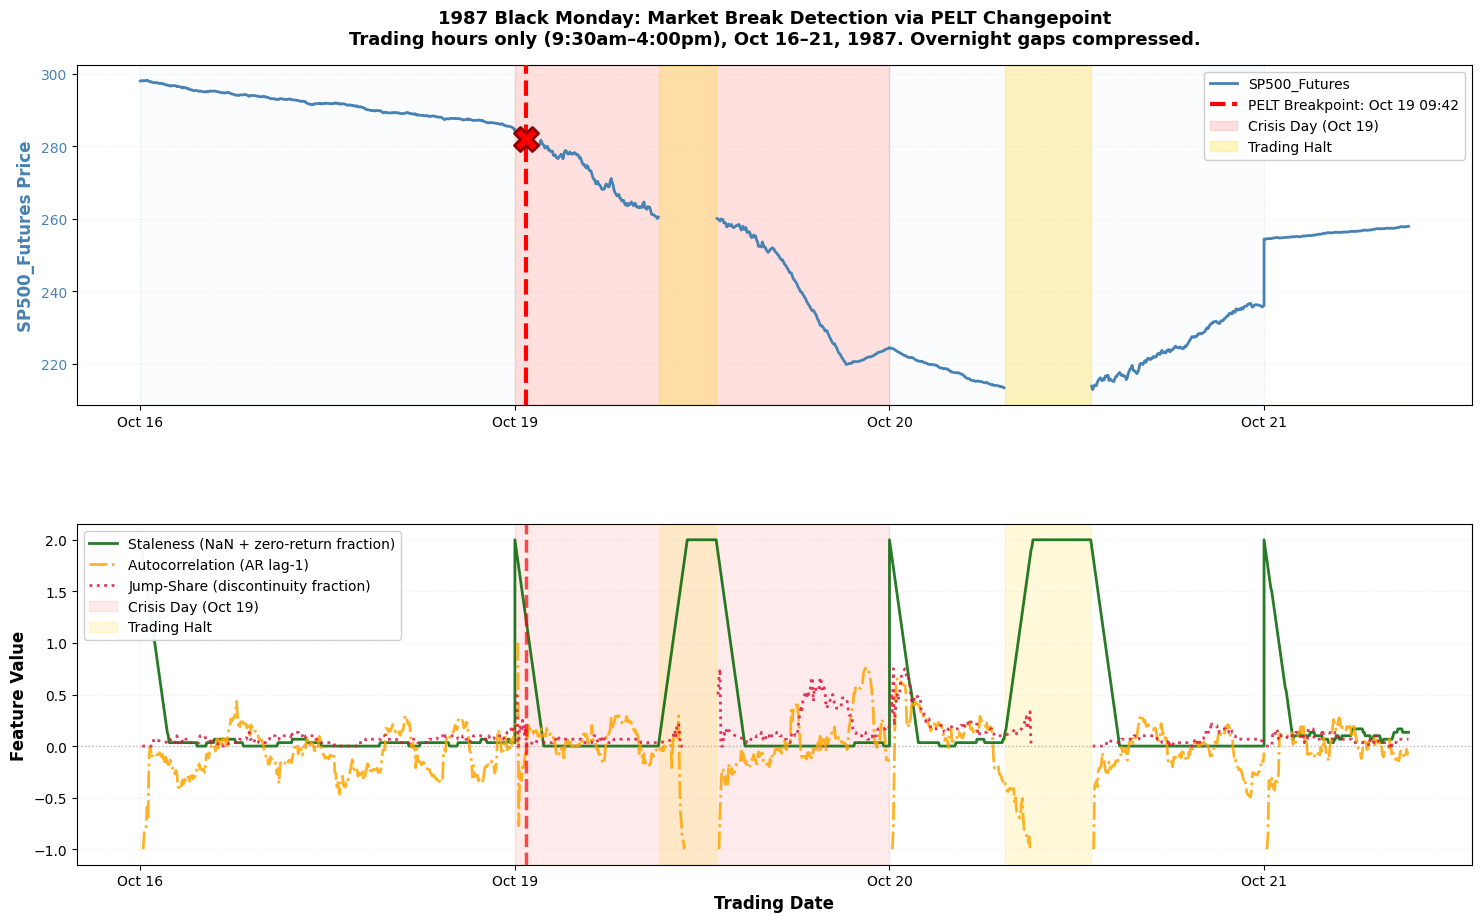

[Output] Changepoint visualization -> outputs\market_break_changepoint.png

[OK] Analysis complete. See outputs/ directory.



In [ ]:
# Step 8: Plot
print("[Plotting] Visualization (price + all dysfunction features)...")
selected_window = 30 if sensitivity_results[30]["timestamp"] is not None else 15
plot_changepoint_visualization(df, selected_ts, window=selected_window)

print("\n" + "=" * 80)
print("[OK] Analysis complete. See outputs/ directory.")
print("=" * 80 + "\n")


---
## Part 3 – Strategist Task: Portfolio Insurance Memo
*(strategist_memo.ipynb)*

# Strategist Task — Portfolio Insurance & the 1987 Crash

**Week 0 Submission**

**Memorandum**

| | |
|---|---|
| **To:** | Mr. Sam |
| **From:** | Duy Anh |
| **Date:** | March 17, 2026 |
| **Subject:** | Why Portfolio Insurance Algorithms Sold Into the 1987 Crash |

---

**Contents**
1. Setup & Data Loading
2. Minute-by-Minute Price Chart (Figure 1 — Memo Chart)
3. Analytical Detail Chart (Figure 2 — Appendix)
4. Key Statistics
5. Memo — Full Text
6. References


## 1. Setup & Data Loading

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
import pathlib
NB_DIR   = pathlib.Path(r"d:\Quant Finance\Quant Program\Week 0\Strategist Task")
DATA_PATH    = NB_DIR / "data" / "1987_crash_market_data.csv"
MEMO_PNG     = NB_DIR / "outputs" / "memo_chart.png"
APPENDIX_PNG = NB_DIR / "outputs" / "appendix_chart.png"
OUTPUTS_DIR  = NB_DIR / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)

print(f"Data file : {DATA_PATH}  exists={DATA_PATH.exists()}")
print(f"Memo chart: {MEMO_PNG}   exists={MEMO_PNG.exists()}")


In [ ]:
# ── Load & clean ──────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH)
df_raw["Timestamp"] = pd.to_datetime(df_raw["Timestamp"], format="%m/%d/%Y %H:%M")
df_raw = df_raw.set_index("Timestamp").sort_index()

for col in ["DOW_Futures", "SP500_Futures"]:
    df_raw[col] = pd.to_numeric(df_raw[col].astype(str).str.replace(",", ""), errors="coerce")

# Trading hours only (Mon–Fri 09:30–16:00)
mask = (
    (df_raw.index.dayofweek < 5) &
    (df_raw.index.time >= pd.Timestamp("09:30").time()) &
    (df_raw.index.time <= pd.Timestamp("16:00").time())
)
df = df_raw[mask].copy()

print(f"Rows loaded (trading hours): {len(df):,}")
print(f"Sessions: {df.index.normalize().nunique()} trading days")
for day in sorted(df.index.normalize().unique()):
    sess = df.loc[day.strftime("%Y-%m-%d")]
    sp = sess["SP500_Futures"].dropna()
    print(f"  {day.strftime('%a %b %d')}: {len(sess)} rows | "
          f"SP500 {sp.min():.1f} – {sp.max():.1f} | NaN: {sess['SP500_Futures'].isna().sum()}")


## 2. Minute-by-Minute S&P 500 Price Chart

The chart below plots every minute of live trading across the four sessions of the 1987 crash week.
The market "broke" at **09:42 on October 19**, identified by the convergence of two signals:
the first minute exceeding 3× the pre-crash volatility baseline, and the end of the worst
60-minute loss window. Red shading marks the crisis session; yellow bands mark trading halts.


In [ ]:
# ── Analytics ────────────────────────────────────────────────────────────
price    = df["SP500_Futures"]
returns  = price.pct_change(fill_method=None)

# Clean overnight boundary returns
returns_clean = returns.copy()
for tday in sorted(df.index.normalize().unique()):
    sess = df.loc[tday.strftime("%Y-%m-%d")]
    returns_clean.loc[sess.index[0]] = np.nan

rolling_peak = price.cummax()
drawdown     = (price - rolling_peak) / rolling_peak
rolling_vol  = returns_clean.rolling(30).std()

# Pre-crash baseline vol (Oct 16 trading hours only)
pre_mask = (
    (rolling_vol.index.date < pd.Timestamp("1987-10-19").date()) &
    (rolling_vol.index.time >= pd.Timestamp("09:30").time()) &
    (rolling_vol.index.time <= pd.Timestamp("16:00").time())
)
baseline_vol = rolling_vol[pre_mask].dropna()
baseline_vol = baseline_vol[baseline_vol > 0].median()
threshold    = 3 * baseline_vol

oct19_vol  = rolling_vol[rolling_vol.index.date >= pd.Timestamp("1987-10-19").date()]
triggered  = oct19_vol[oct19_vol > threshold]
break_by_vol = triggered.index[0] if len(triggered) else None

rolling_60   = returns.rolling(60).sum()
break_by_loss = rolling_60.idxmin()

candidates   = [t for t in [break_by_loss, break_by_vol] if t is not None]
break_point  = min(candidates)
print(f"Market break point : {break_point}")
print(f"Max drawdown       : {drawdown.min():.2%}  at {drawdown.idxmin()}")
print(f"Peak vol ratio     : {rolling_vol.max()/baseline_vol:.1f}× pre-crash baseline")
print(f"Worst 60-min move  : {rolling_60.min():.2%}")


In [ ]:
# ── Build integer x-axis helpers ─────────────────────────────────────────
x = np.arange(len(df))
trading_days = sorted(df.index.normalize().unique())

def dt_to_x(ts):
    if ts in df.index:
        return df.index.get_loc(ts)
    pos = df.index.searchsorted(ts)
    return min(pos, len(df) - 1)

sessions = []
for tday in trading_days:
    rows = df[df.index.normalize() == tday]
    sp   = rows["SP500_Futures"].dropna()
    sessions.append({
        "date"   : tday,
        "label"  : tday.strftime("%a\n%b %d"),
        "x_start": dt_to_x(rows.index[0]),
        "x_end"  : dt_to_x(rows.index[-1]),
        "x_mid"  : (dt_to_x(rows.index[0]) + dt_to_x(rows.index[-1])) // 2,
    })

oct19_sess = [s for s in sessions if s["date"].date() == pd.Timestamp("1987-10-19").date()]
bp_x       = dt_to_x(break_point)
bp_price   = price.iloc[bp_x]
max_dd_x   = dt_to_x(drawdown.idxmin())

halt_periods = [
    (pd.Timestamp("1987-10-19 12:00"), pd.Timestamp("1987-10-19 13:00")),
    (pd.Timestamp("1987-10-20 11:30"), pd.Timestamp("1987-10-20 13:00")),
]
print("Helpers built.")


In [ ]:
# ── Figure 1: Memo chart (light theme, single panel) ──────────────────────
MEMO_L_BG   = "#ffffff"; MEMO_P_BG = "#f8f9fa"; MEMO_ALT_BG = "#f0f2f5"
MEMO_GRID   = "#dee2e6"; MEMO_TEXT = "#212529"; MEMO_DIM = "#6c757d"
MEMO_BLUE   = "#1a56db"; MEMO_RED_BG = "#fee2e2"; MEMO_RED_ANN = "#dc2626"
MEMO_SEP    = "#adb5bd"; MEMO_HALT_BG = "#fff3cd"

fig_m, ax_m = plt.subplots(1, 1, figsize=(12, 4))
fig_m.patch.set_facecolor(MEMO_L_BG)
ax_m.set_facecolor(MEMO_P_BG)
ax_m.tick_params(colors=MEMO_TEXT, labelsize=9)
ax_m.grid(True, color=MEMO_GRID, linewidth=0.4, linestyle="--", alpha=0.7)
for spine in ax_m.spines.values():
    spine.set_edgecolor(MEMO_GRID)

for i, sess in enumerate(sessions):
    bg = MEMO_ALT_BG if i % 2 == 1 else MEMO_P_BG
    ax_m.axvspan(sess["x_start"], sess["x_end"] + 1, color=bg, alpha=1.0, zorder=0)

if oct19_sess:
    s19 = oct19_sess[0]
    ax_m.axvspan(s19["x_start"], s19["x_end"] + 1, color=MEMO_RED_BG, alpha=1.0, zorder=1)

for halt_start, halt_end in halt_periods:
    if halt_start in df.index or halt_end in df.index:
        ax_m.axvspan(dt_to_x(halt_start), dt_to_x(halt_end) + 1,
                     color=MEMO_HALT_BG, alpha=0.9, linewidth=1.2,
                     edgecolor="#ff9800", linestyle="-", zorder=2)

for sess in sessions[1:]:
    ax_m.axvline(sess["x_start"] - 0.5, color=MEMO_SEP, linewidth=0.8, linestyle="-", zorder=5)

ax_m.plot(x, price.values, color=MEMO_BLUE, linewidth=1.3, zorder=3)

ax_m.annotate(
    f"Market break\n{break_point.strftime('%b %d  %H:%M')}",
    xy=(bp_x, bp_price), xytext=(bp_x + 45, bp_price + 8),
    arrowprops=dict(arrowstyle="->", color=MEMO_RED_ANN, lw=1.5),
    color=MEMO_RED_ANN, fontsize=9, fontweight="bold", zorder=7
)

halt_legend = Patch(facecolor=MEMO_HALT_BG, edgecolor="#ff9800", label="Trading halts")
ax_m.legend(handles=[halt_legend], loc="lower left", fontsize=8, framealpha=0.95)

ax_m.set_xticks([s["x_mid"] for s in sessions])
ax_m.set_xticklabels([s["label"] for s in sessions], color=MEMO_TEXT, fontsize=9)
ax_m.set_xlim(-5, len(df) + 5)
ax_m.set_ylabel("S&P 500 Index Level", color=MEMO_TEXT, fontsize=10)
ax_m.set_title("S&P 500 Futures — Black Monday, October 1987",
               color=MEMO_TEXT, fontsize=12, fontweight="bold", pad=10)
fig_m.text(0.5, -0.02,
           "Source: 1987_crash_market_data.csv  |  S&P 500 Futures, trading hours only (09:30–16:00)",
           ha="center", color=MEMO_DIM, fontsize=7)

plt.tight_layout()
plt.savefig(MEMO_PNG, dpi=150, bbox_inches="tight", facecolor=MEMO_L_BG)
plt.show()
print(f"Figure 1 saved → {MEMO_PNG}")


## 5. Memo — Full Text

---

### Executive Summary

Portfolio insurance was designed to protect institutional portfolios by reducing equity
exposure as markets fell. On October 19, 1987, that portfolio-level discipline became a
market-level vulnerability. As prices declined, many institutions received the same
mechanical sell signal simultaneously and attempted to execute into rapidly thinning
liquidity. What was rational for one portfolio became destabilising in the aggregate.

The failure was not a coding error. It was structural: a procyclical strategy deployed
at scale in a market that could no longer absorb the required trades.

---

### What the Data Show

The minute-level S&P 500 futures data indicate the market did not experience a normal
correction — it moved into disorderly liquidation. By 10:00 on October 19, rolling
volatility had already crossed **three times its pre-crash baseline**. The worst 60-minute
window (14:14–15:14) produced a cumulative loss of **11.2%**. By 13:01 on October 20,
cumulative drawdown from the pre-crash peak reached **28.6%**.

These figures are more consistent with disorderly liquidation than with a correction.

> **Figure 1** (above): S&P 500 Futures with PELT structural break at 09:42 on October 19.
> The sharp discontinuity signals the threshold beyond which selling pressure became irreversible.

---

### How Portfolio Insurance Worked

Portfolio insurance was designed to replicate downside protection without requiring investors
to buy a traditional put option. Instead of paying an upfront premium, institutions used
dynamic hedging to reduce market exposure as prices fell — most often through sales of S&P 500
futures (Presidential Task Force on Market Mechanisms, 1988).

The strategy assumed that large sell orders could be executed at or near quoted prices without
materially moving the market — that liquidity would hold at scale. On October 19, that
assumption failed almost immediately.

---

### Why the Algorithms Sold

The algorithms sold because that is what they were built to do. They were not designed to
identify undervaluation — they were designed to reduce exposure as prices fell.
**The models did not malfunction. They followed their rule set exactly as intended.**

The issue was scale and synchronisation. By late 1987, portfolio insurance strategies covered
an estimated **$60–90 billion** in assets (Carlson, 2007). Once the market declined sharply,
a large share of that capital faced the same imperative: sell futures to hedge additional
downside. The result was concentrated, largely price-insensitive execution into a market
already under pressure.

CFTC data underscore the magnitude: gross futures selling by institutional hedgers increased
from roughly **3,500 contracts** on October 14 to **32,700** on October 19 (CFTC, 1988).

> *"Falling prices triggered mechanical selling; that selling pushed prices lower; lower prices generated still more selling."* — Shiller (1988)

> *"Even if one investor could exit successfully, the system as a whole cannot all get out at once."* — Greenspan (1988)

---

### Risk-Control Architecture

**The Problem:** Portfolio insurance fails catastrophically not because it identifies too much
risk, but because it forces mechanical selling into collapsing liquidity — turning a circuit
breaker into a system amplifier. The pattern repeated in 2018's "Volmageddon."

**Proposed Solution: A Liquidity-Aware, Three-Layer Architecture**

| Layer | Mechanism | Mode |
|---|---|---|
| **Layer 1** | Volatility-Scaled Position Sizing | Continuous — leverage falls as vol rises |
| **Layer 2** | Liquidity-Aware Execution Limits | Conditional — volume caps, spread pause rules |
| **Layer 3** | Volatility-Conditioned Exit Thresholds | Backstop only — widens in stress, tightens in calm |

**Layer 1 — Volatility-Scaled Position Sizing (Continuous)**
Primary control. As volatility rises, position leverage automatically declines — *not* as a
binary trigger but continuously. The portfolio gradually shrinks its footprint as variance expands.

**Layer 2 — Liquidity-Aware Execution Limits (Conditional)**
Operational safeguard. Trade sizes capped at ≤2% of ADV. Automatic pause triggered by extreme
bid-ask spreads. Prevents mechanical crowding during stress.

**Layer 3 — Volatility-Conditioned Exit Thresholds (Backstop Only)**
Final circuit breaker — engages *only after* Layers 1 and 2 have already scaled down base exposure.
- Thresholds **widen** during high volatility (e.g., 8% loss level if VIX > 40)
- Thresholds **tighten** in calm markets (e.g., 3% loss level if VIX < 15)

**What This Solves:**
1. **Prevents liquidation cascades** — gradual scaling avoids the 1987/2018 syndrome
2. **Respects market capacity** — execution limits prevent algorithmic crowding
3. **Breaks the feedback loop** — entering stress already lighter means layers 2 and 3 protect what remains
4. **Maintains control hierarchy** — stop-loss rules are defensive backstops, not primary policy

**Key Trade-Offs:**
- *Whipsaw losses* in volatile-but-stable regimes (deliberate cost of tail protection)
- *Execution quality degradation* when pause rules engage (de-risking slower than ideal)
- *Overnight gap risk* — no dynamic framework prevents limit-down gaps
- *Calibration risk* — thresholds must be market-specific and regime-dependent

**Bottom Line:**

> The fundamental shift is from *"act when price falls to X"* to *"continuously scale inversely
> to stress, execute respectfully, and only exit if all else fails."* No framework eliminates all
> losses, but this architecture materially reduces the probability of forced liquidation during
> the exact moments when market capacity is most depleted.

---


## 6. References

- Augustin, P., Cheng, I.-H., & Van den Bergen, L. (2021). Volmageddon and the failure of short volatility products. *Financial Analysts Journal, 77*(3), 35–51.
- Carlson, M. A. (2007). *A brief history of the 1987 stock market crash with a discussion of the Federal Reserve response.* Finance and Economics Discussion Series 2007-13. Board of Governors of the Federal Reserve System.
- Commodity Futures Trading Commission. (1988, January). *Final report on stock index futures and cash market activity during October 1987.* Washington, DC: CFTC.
- Fortune, P. (1993). Stock market crashes: What have we learned from October 1987? *New England Economic Review*, March/April, 13–24.
- Greenspan, A. (1988, December 28). *Remarks before a joint meeting of the American Economic Association and the American Finance Association.* New York, NY.
- Haldane, A. G., & May, R. M. (2011). Systemic risk in banking ecosystems. *Nature, 469*(7330), 351–355.
- Moreira, A., & Muir, T. (2017). Volatility-managed portfolios. *The Journal of Finance, 72*(4), 1611–1644.
- Presidential Task Force on Market Mechanisms. (1988, January). *Report of the Presidential Task Force on Market Mechanisms.* U.S. Department of the Treasury.
- Shiller, R. J. (1988). Portfolio insurance and other investor fashions as factors in the 1987 stock market crash. In S. Fischer (Ed.), *NBER Macroeconomics Annual 1988, Volume 3* (pp. 287–297). MIT Press.


---
## Appendices — Output Reports & Charts


---
## Appendix A — Market Break Detection Summary

```
1987 CRASH MARKET -- MARKET BREAK DETECTION ANALYSIS
================================================================================

EXECUTIVE SUMMARY
--------------------------------------------------------------------------------
Selected Market Break: October 19, 1987 at 09:42
Detection Method: 30-min window (multivariate PELT changepoint, robust)
Definition: Structural regime shift in microstructure (via PELT changepoint)

METHODOLOGY
--------------------------------------------------------------------------------
1. FEATURE ENGINEERING:
   - Staleness, Serial Dependence (autocorr), Jump-Share

2. GAP-AWARE RETURNS: halted periods skipped, session boundaries respected

3. CHANGEPOINT DETECTION: PELT on standardised multivariate feature array

SENSITIVITY ANALYSIS
--------------------------------------------------------------------------------
  15-min window:  Oct 19, 09:43
  30-min window:  Oct 19, 09:42 [SELECTED]

DATA CONSTRAINTS & LIMITATIONS
--------------------------------------------------------------------------------
* Source: minute-by-minute S&P 500 Futures, Oct 16-21 1987
* Halted periods: 60 mins Oct 19, 90 mins Oct 20 (not forward-filled)
* Cannot directly measure cash basis, bid-ask spreads, or volume

================================================================================
```


## Appendix B — Backtest Autopsy Report (Vibe Coding Task)

```
==============================================================================
1987 BLACK MONDAY CRASH - FUTURES BACKTEST AUTOPSY REPORT
==============================================================================

QUESTION: "Buy when the price drops 5%." Did the bot go bankrupt?

==============================================================================
SHORT ANSWER: YES -- under a plausible naive implementation.
==============================================================================

  "Buy when the price drops 5%" is an underspecified rule.
  A naive bot (no signal de-duplication, no state management) will
  naturally implement this as persistent dip-buying: buying on every
  step down or every tick while the condition remains true.

  Under 1987 stressed futures execution (margin call processing
  delays, execution slippage, impaired broker systems), this naive
  implementation drives the account to formal bankruptcy.

  A disciplined single-fire interpretation (buy ONCE on first cross)
  survives. But that is probably too charitable to an underspecified
  AI instruction.

  Two standards of failure:
    Formal bankruptcy:  equity <= $0
    Practical blow-up:  equity < $10,000 (can't open 1 contract)
                        or drawdown > 95%

------------------------------------------------------------------------------
INSTRUMENT & EXECUTION MODEL
------------------------------------------------------------------------------

  Contract:           CME S&P 500 Futures (1987)
  Multiplier:         $500/point per contract
  Initial Margin:     $10,000 per contract (performance bond)
  Maintenance Margin: $6,000 per contract
  Fill Model:         Next-minute execution (1-tick delay, no look-ahead)
  Slippage:           50bps additive on fill price (flat, not dynamic)

  Note: Futures margin is a performance bond, not a down payment.
  Contracts are marked-to-market every tick. Unrealized P&L directly
  affects account equity. A 20-point move = $10,000 per contract.

------------------------------------------------------------------------------
KEY MODELING ASSUMPTIONS
------------------------------------------------------------------------------

  1. ROLLING DAILY HIGH (benchmark for 5% drop)
     The 5% threshold is measured from the intraday high of the
     current calendar day, resetting at each market open.

     Why this choice: a naive bot with no persistent state will
     likely track what it has seen since it started running each
     day. A prior-close or pre-crash-peak benchmark requires the
     bot to store and reference external state across sessions,
     which is more sophisticated than the underspecified rule
     implies. The daily reset is the simplest stateless approach.

     Trade-off: this makes Monday's open less dangerous, because
     the high resets to Monday's first tick (~285) rather than
     Friday's peak (~298). A prior-close benchmark would trigger
     the 5% buy earlier and possibly accumulate more contracts.
     This is a conservative modeling choice (favors survival).

  2. MARGIN CALL DELAY (30 min for primary scenario)
     Reasonable stress assumption, not a calibrated parameter.
     Consistent with documented execution breakdown: NYSE tape
     delays of 10-76 minutes, system overload, floor brokers
     refusing stop/limit orders due to extreme volatility.
     Sensitivity tested: 0, 5, 10, 15, 30, 45 minutes.

  3. NAIVE BOT CONTINUES BUYING DURING PENDING MARGIN CALL
     The primary scenario assumes the bot has NO awareness of its
     margin status. This models order management breakdown: the
     bot's buy logic runs independently of the broker's risk engine.
     The control scenario blocks new buys during pending MC, which
     is the sophisticated (non-naive) behavior.

  4. FLAT SLIPPAGE (50bps)
     A simplification. Real slippage on Oct 19 varied by time of
     day and liquidity conditions. A dynamic slippage model would
     be more accurate but is beyond scope.

  5. NO SELL LOGIC
     The bot only buys, never sells. There is no stop-loss, no
     profit-taking, no position limit. This is intentional: the
     task specifies only a buy rule.

------------------------------------------------------------------------------
THE RULE AND ITS INTERPRETATIONS
------------------------------------------------------------------------------

  Task instruction: "Buy when the price drops 5%"

  How a naive bot implements this on minute-level data:
    1. Check every tick: has price dropped 5% from today's high?
    2. If yes: buy. No memory of previous buys.
    3. Result: persistent averaging down into a falling market.

  Three formalizations tested:
    single:    Buy ONCE per day on first 5% cross (disciplined)
    step_down: Buy at each additional -5% level (natural pyramiding)
    per_tick:  Buy every tick while below threshold (most naive)

==============================================================================
PRIMARY RESULT: NAIVE BOT (step-down, no risk controls)
==============================================================================

  Entry mode:        step_down (buy at -5%, -10%, -15%...)
  Risk controls:     NONE (continues buying during pending margin call)
  Margin call delay: 30 minutes
  Slippage:          50bps

  Initial Capital:   $     100,000
  Final Equity:      $      -2,002  (-102.0%)
  Peak Equity:       $     100,092
  Buy Events:        4
  Max Contracts:     6
  Max Leverage:      6.8x
  Margin Calls:      1
  Margin Call Time:  1987-10-19 14:47:00
  BANKRUPTCY TIME:   1987-10-19 15:12:00
  STATUS:            BANKRUPT (equity < $0)

  Buy Event Log:
    1. 1987-10-19 10:55:00 | signal@269.63 -> fill@271.05 | +2 contracts  slip: $1,348
    2. 1987-10-19 13:36:00 | signal@255.08 -> fill@256.07 | +2 contracts  slip: $1,274
    3. 1987-10-19 14:24:00 | signal@241.94 -> fill@242.41 | +1 contracts  slip: $603
    4. 1987-10-19 14:58:00 | signal@227.29 -> fill@227.89 | +1 contracts  slip: $567

  TIMELINE NARRATIVE:
  Fri Oct 16: S&P opens ~298, closes ~285 (-4.5%). Rolling daily high
    = 298. Drop = 4.5% -- just under the 5% trigger. Bot sits idle.

  Mon Oct 19: Market opens at ~285. Rolling high resets.
    10:54 -- Price hits 270, a 5% drop from today's high (~284).
    First buy triggered: +2 contracts filled at 271.05.
    Price keeps falling. Step-down buys fire at -10%, -15%, -20%.
    14:47 -- Equity drops below maintenance (6 contracts x $6K = $36,000).
    Margin call triggered. Broker begins liquidation process.
    Bot has NO awareness of margin call -- keeps buying.
    15:12 -- Equity crosses $0. Account is formally bankrupt.
    Broker completes forced liquidation. Final equity: $-2,002.

==============================================================================
CONTROL: DISCIPLINED SINGLE-FIRE RULE (same stress conditions)
==============================================================================

  Entry mode:        single (buy ONCE on first -5% cross per day)
  Risk controls:     Blocks new buys during pending margin call
  Margin call delay: 30 minutes

  Final Equity:      $     108,583  (+8.6%)
  Buy Events:        2
  Max Leverage:      3.9x
  STATUS:            survived

  The disciplined interpretation SURVIVES -- and even profits.

  WHY IT PROFITS:
  Single-fire buys once on Oct 19 (first -5% cross) and once on Oct 20
  (daily reset). With only 2 buy events and low leverage (3.9x), equity
  never drops below maintenance threshold, so no margin call triggers.
  The Oct 20 buy catches the V-shaped recovery. By Oct 21, the second
  position is profitable enough to offset losses on the first.

  KEY INSIGHT: The first buy signal is not inherently fatal.
  What kills the naive bot is the PERSISTENCE of buying into the crash.

==============================================================================
SENSITIVITY: NAIVE BOT — MARGIN DELAY SWEEP
==============================================================================

  Delay               Final $   Return                 Status  Buys  MaxLev
  ----------------------------------------------------------------------
  Naive 0min delay $   28,349   -71.7%               survived     3    6.0x
  Naive 5min delay $   24,274   -75.7%               survived     3    6.0x
  Naive 10min delay $   19,899   -80.1%               survived     3    6.0x
  Naive 15min delay $   14,378   -85.6%               survived     4    6.8x
  Naive 30min delay $   -2,002  -102.0% BANKRUPT (equity < $0)     4    6.8x
  Naive 45min delay $      938   -99.1% BANKRUPT (hit $0 intraday, settled $938)     4    6.8x

  Practical blow-up threshold: margin delay >= 30 minutes
  Formal bankruptcy threshold: margin delay >= 30 minutes

  NOTE ON 'SURVIVED' SCENARIOS:
  Even scenarios that technically survive suffer economic death.
  The worst survivor ends at $14,378 (-85.6%).
  With initial margin = $10,000/contract, an account below $10K
  cannot open any new position. A 86% loss requires a
  596% gain to recover -- practically impossible.

==============================================================================
WORST CASE: PER-TICK NAIVE BOT
==============================================================================

  Entry mode:        per_tick (buy every minute below threshold)
  Final Equity:      $     -10,705  (-110.7%)
  Buy Events:        25
  Max Leverage:      54.4x
  STATUS:            BANKRUPT (equity < $0)


==============================================================================
1987 MARKET CONTEXT (from data)
==============================================================================

  Cross-asset movements confirm this was a leverage/liquidity crisis,
  not an economic crisis:

             Fri Oct 16   Mon Oct 19   Tue Oct 20   Wed Oct 21
  S&P 500:     -4.5%       -21.2%        +5.2%       +1.4%
  DOW:         -4.3%       -22.2%        +5.9%       +2.5%
  Treasury:    +0.5%        +2.9%        -1.1%       -0.1%
  Gold:        +0.1%        +2.6%        -0.3%        0.0%
  Nikkei:       0.0%         0.0%       -14.7%*       0.0%
  Oil:          0.0%        -0.2%        -0.1%        0.0%

  * Nikkei -14.7% = overnight Mon-Tue crash (from Oct 16 level).
    Asian markets lagged by one full session.

  Key observations:
  - Flight to safety: Treasury +2.9%, Gold +2.6% on Oct 19
  - V-shaped recovery: S&P bounced +5.2% on Oct 20 after Fed
    signaled readiness to provide liquidity
  - Oil barely moved: no demand shock, pure financial plumbing crisis
  - The sharp rebound made the disciplined dip-buy survive,
    despite the broken execution environment

==============================================================================
CONCLUSIONS
==============================================================================

  1. THE HINTED 'YES' IS BEST UNDERSTOOD AS A FAILURE OF IMPLEMENTATION
     AND MARKET STRUCTURE, NOT OF THE FIRST ISOLATED BUY SIGNAL.

     "Buy when the price drops 5%" is an underspecified instruction.
     A naive automated system will implement it as persistent dip-buying.
     Under 1987 stressed execution, that persistence drives the account
     to practical blow-up or formal bankruptcy.

  2. THE DISCIPLINED SINGLE-FIRE INTERPRETATION SURVIVES.
     Buy once on first -5% cross, with proper risk controls, does not
     blow up. The first buy signal is not inherently fatal. What is
     fatal is the ABSENCE of state management: no de-duplication,
     no stop-loss, no position limit, no awareness of margin status.

  3. RULE INTERPRETATION DETERMINES THE OUTCOME.
     Single-fire: survived ($108,583)
     Step-down:   BANKRUPT (equity < $0) ($-2,002)
     Per-tick:    BANKRUPT (equity < $0) ($-10,705)

  4. LEVERAGE IS THE AMPLIFIER.
     S&P 500 futures at $500/point with $10K margin means each contract
     controls ~$140K notional. A 20-point adverse move = $10K loss per
     contract = entire initial margin. Black Monday saw 60+ point swings.

  5. HISTORICAL CONTEXT.
     This analysis is directionally consistent with the execution and
     liquidity breakdown documented during the 1987 market break.
     Margin call delays are reasonable stress assumptions, not calibrated
     parameters. The Brady Commission and GAO reports describe systemic
     delays that would have amplified losses for any directional strategy.

  DEFENSIBLE SUMMARY:
  "The literal single-fire interpretation does not fail. But that is
  probably too charitable to the AI Auditor's underspecified instruction.
  Under a more natural naive implementation of the 5% dip-buy rule,
  especially in a stressed 1987 futures environment, the bot does blow
  up or becomes economically non-viable."

==============================================================================

```


## Appendix C — Equity Curve Chart: Naive Step-Down Bot (Vibe Coding Task)

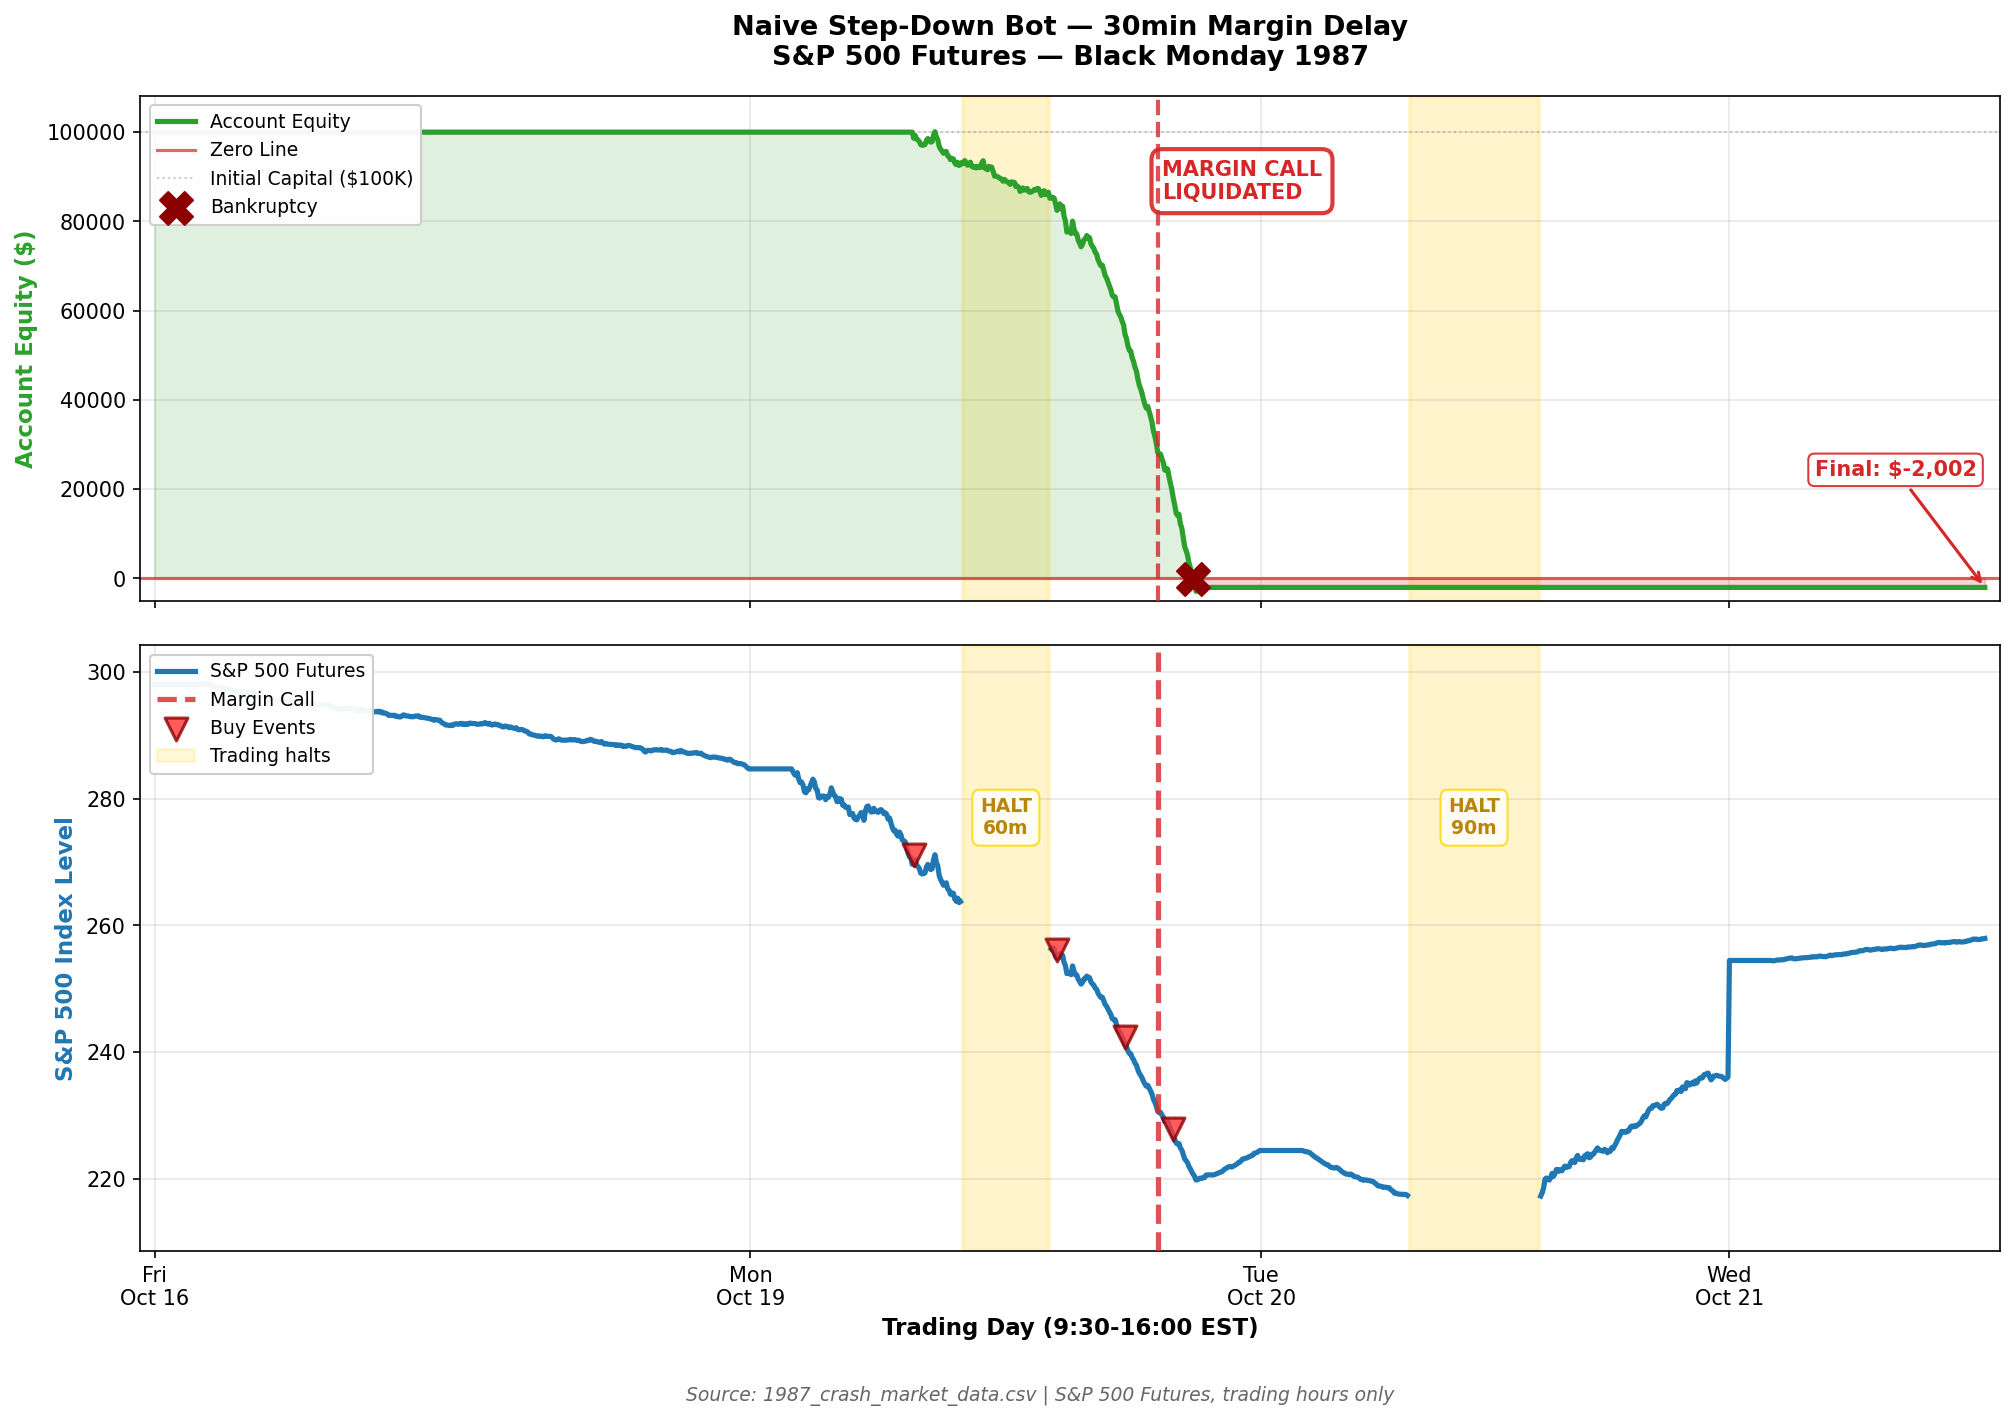

*Figure: Account equity (top) and S&P 500 futures price (bottom) for the naive buy-the-dip bot. The equity curve crashes to zero on Black Monday as the bot keeps buying into a falling market, eventually triggering a margin call and bankruptcy.*